<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/Integrity_Aware_Named_Entity_Recognition_with_Encoder_Only_Transformer_on_CoNLL_2003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 01 — Library Installation
# Komentar akademik:
# Instalasi dilakukan secara eksplisit agar seluruh dependensi penelitian,
# evaluasi model, visualisasi, deployment, dan dashboard dapat direplikasi.

!pip -q install datasets transformers evaluate seqeval accelerate graphviz pandas numpy scikit-learn matplotlib streamlit pyngrok joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 104.3 MB/s eta 0:00:00


In [ ]:
# Cell 02 — Import Modules and Reproducibility Setup
# Komentar akademik:
# Cell ini mengatur library utama, seed, deteksi GPU, dan informasi lingkungan komputasi.
# Tujuannya adalah menjaga eksperimen lebih konsisten dan dapat direproduksi.

import os
import sys
import json
import random
import platform
import inspect
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from datasets import load_dataset, load_from_disk, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed as hf_set_seed
)
import evaluate
from seqeval.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

SEED = 42

def set_all_seeds(seed=SEED, deterministic=True):
    # Komentar akademik:
    # Pengaturan seed membantu mengurangi variasi hasil eksperimen.
    # Namun, determinisme penuh tidak selalu terjamin pada seluruh hardware/GPU.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    hf_set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_all_seeds(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Program Title: Integrity-Aware Named Entity Recognition with Encoder-Only Transformer on CoNLL-2003")
print("Execution Environment Summary")
print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Program Title: Integrity-Aware Named Entity Recognition with Encoder-Only Transformer on CoNLL-2003
Execution Environment Summary
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA Available: True
Device: cuda
GPU: Tesla T4


In [ ]:
# Cell 03 — Experiment Configuration and Cache Policy
# Komentar akademik:
# Cell ini mengatur konfigurasi eksperimen, mode debugging, model kandidat,
# strategi alignment, strategi loss, dan folder cache.
# Cache digunakan agar dataset dan tokenized dataset tidak diproses berulang-ulang.

FAST_RUN = True
SAVE_DIR = Path("./integrity_aware_ner_outputs")
SAVE_DIR.mkdir(exist_ok=True, parents=True)

# Komentar akademik:
# HF_DATASETS_CACHE_DIR menyimpan cache bawaan Hugging Face.
# DATASET_DISK_PATH menyimpan DatasetDict CoNLL-2003 setelah load pertama.
# TOKENIZED_CACHE_DIR menyimpan hasil tokenisasi agar proses map/tokenisasi tidak diulang.
HF_DATASETS_CACHE_DIR = SAVE_DIR / "hf_datasets_cache"
DATASET_DISK_PATH = SAVE_DIR / "conll2003_datasetdict"
TOKENIZED_CACHE_DIR = SAVE_DIR / "tokenized_cache"

HF_DATASETS_CACHE_DIR.mkdir(exist_ok=True, parents=True)
TOKENIZED_CACHE_DIR.mkdir(exist_ok=True, parents=True)

# Komentar akademik:
# Untuk validasi pipeline awal, gunakan model ringan.
# Untuk eksperimen final, aktifkan minimal dua model encoder-only.
MODEL_CANDIDATES = [
    "distilbert-base-cased",
    # "bert-base-cased",  # Aktifkan untuk eksperimen final yang lebih kuat.
]

# Komentar akademik:
# Dua strategi alignment diuji agar efek subword-label alignment dapat dianalisis.
ALIGNMENT_VARIANTS = [
    {"name": "strict_first_subword", "label_all_tokens": False},
    {"name": "all_subtokens", "label_all_tokens": True},
]

# Komentar akademik:
# Standard loss menjadi baseline; weighted loss menjadi teknik mitigasi imbalance.
LOSS_VARIANTS = [
    {"name": "standard_loss", "weighted": False},
    {"name": "weighted_loss", "weighted": True},
]

# Komentar akademik:
# FAST_RUN=True hanya untuk debugging pipeline.
# Jangan gunakan hasil FAST_RUN sebagai klaim hasil penelitian final.
MAX_TRAIN_SAMPLES = 600 if FAST_RUN else None
MAX_EVAL_SAMPLES = 300 if FAST_RUN else None

NUM_EPOCHS = 2 if FAST_RUN else 5
BATCH_SIZE = 8 if FAST_RUN else 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2

config = {
    "FAST_RUN": FAST_RUN,
    "SEED": SEED,
    "MODEL_CANDIDATES": MODEL_CANDIDATES,
    "ALIGNMENT_VARIANTS": ALIGNMENT_VARIANTS,
    "LOSS_VARIANTS": LOSS_VARIANTS,
    "MAX_TRAIN_SAMPLES": MAX_TRAIN_SAMPLES,
    "MAX_EVAL_SAMPLES": MAX_EVAL_SAMPLES,
    "NUM_EPOCHS": NUM_EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "LEARNING_RATE": LEARNING_RATE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
    "HF_DATASETS_CACHE_DIR": str(HF_DATASETS_CACHE_DIR),
    "DATASET_DISK_PATH": str(DATASET_DISK_PATH),
    "TOKENIZED_CACHE_DIR": str(TOKENIZED_CACHE_DIR),
}

print("Experiment Configuration")
print(json.dumps(config, indent=2))

with open(SAVE_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

Experiment Configuration
{
  "FAST_RUN": true,
  "SEED": 42,
  "MODEL_CANDIDATES": [
    "distilbert-base-cased"
  ],
  "ALIGNMENT_VARIANTS": [
    {
      "name": "strict_first_subword",
      "label_all_tokens": false
    },
    {
      "name": "all_subtokens",
      "label_all_tokens": true
    }
  ],
  "LOSS_VARIANTS": [
    {
      "name": "standard_loss",
      "weighted": false
    },
    {
      "name": "weighted_loss",
      "weighted": true
    }
  ],
  "MAX_TRAIN_SAMPLES": 600,
  "MAX_EVAL_SAMPLES": 300,
  "NUM_EPOCHS": 2,
  "BATCH_SIZE": 8,
  "LEARNING_RATE": 2e-05,
  "WEIGHT_DECAY": 0.01,
  "EARLY_STOPPING_PATIENCE": 2,
  "HF_DATASETS_CACHE_DIR": "integrity_aware_ner_outputs/hf_datasets_cache",
  "DATASET_DISK_PATH": "integrity_aware_ner_outputs/conll2003_datasetdict",
  "TOKENIZED_CACHE_DIR": "integrity_aware_ner_outputs/tokenized_cache"
}


In [ ]:
# Cell 04 — Prior Studies, Research Gap, and Novelty
# Komentar akademik:
# Cell ini mendokumentasikan penelitian terdahulu, gap penelitian, dan novelty.
# Data literatur digunakan sebagai latar belakang konseptual, bukan sebagai hasil eksperimen notebook.

literature = [
    {
        "No": 1,
        "Year": 2022,
        "Authors": "Berragan, Singleton, Calafiore, Morley",
        "Title": "Transformer based named entity recognition for place name extraction from unstructured text",
        "Journal": "International Journal of Geographical Information Science",
        "DOI": "10.1080/13658816.2022.2133125",
        "Gap Insight": (
            "Fokus pada place-name extraction berbasis Transformer. "
            "Belum secara khusus membangun audit bias data, reproducibility control, "
            "dan boundary error analysis pada benchmark CoNLL-2003."
        )
    },
    {
        "No": 2,
        "Year": 2024,
        "Authors": "Khairunnisa, Chen, Komachi",
        "Title": "Improving Domain-Specific NER in the Indonesian Language Through Domain Transfer and Data Augmentation",
        "Journal": "Journal of Advanced Computational Intelligence and Intelligent Informatics",
        "DOI": "10.20965/jaciii.2024.p1299",
        "Gap Insight": (
            "Fokus pada NER bahasa Indonesia berbasis domain transfer dan augmentasi. "
            "Belum menempatkan CoNLL-2003 sebagai benchmark utama untuk integrity-aware evaluation."
        )
    },
    {
        "No": 3,
        "Year": 2024,
        "Authors": "Ullah, Gelbukh, Zamir, Riverón, Sidorov",
        "Title": "Enhancement of Named Entity Recognition in Low-Resource Languages with Data Augmentation and BERT Models",
        "Journal": "Computers",
        "DOI": "10.3390/computers13100258",
        "Gap Insight": (
            "Fokus pada low-resource Urdu NER dengan augmentasi data dan BERT. "
            "Belum membangun framework evaluasi bias, alignment, dan boundary error pada CoNLL-2003."
        )
    },
    {
        "No": 4,
        "Year": 2025,
        "Authors": "Zheng, Lu, Li, Zheng, Pan",
        "Title": "CyberDualNER: A Dual-Stage Approach for Few-Shot Named Entity Recognition in Cybersecurity",
        "Journal": "Electronics",
        "DOI": "10.3390/electronics14091791",
        "Gap Insight": (
            "Fokus pada few-shot NER di domain cybersecurity. "
            "Belum mengevaluasi class imbalance, reproducibility, dan BIO consistency pada benchmark umum CoNLL-2003."
        )
    },
    {
    "No": 5,
    "Year": 2025,
    "Authors": "Wu, Chen, Yan",
    "Title": "Named Entity Recognition Based on Multi-Class Label Prompt Selection and Core Entity Replacement",
    "Journal": "Applied Sciences",
    "DOI": "https://doi.org/10.3390/app15116171",
    "Gap Insight": (
        "Fokus pada prompt selection dan core entity replacement. "
        "Belum fokus pada subword-label alignment audit dan standard versus weighted loss comparison "
        "untuk encoder-only Transformer pada CoNLL-2003."
    )
}
    ,
]

literature_df = pd.DataFrame(literature)
pd.set_option("display.max_colwidth", 170)

print("Prior Studies and Research Gap")
display(literature_df)

print("Proposed Novelty")
print(
    "Integrity-Aware Encoder-Only Transformer Framework for CoNLL-2003 NER: "
    "integrating bias audit, reproducibility control, subword-label alignment audit, "
    "class-weighted loss comparison, BIO repair evaluation, and boundary error analysis."
)

Prior Studies and Research Gap


,No,Year,Authors,Title,Journal,DOI,Gap Insight
0,1,2022,"Berragan, Singleton, Calafiore, Morley",Transformer based named entity recognition for place name extraction from unstructured text,International Journal of Geographical Information Science,10.1080/13658816.2022.2133125,"Fokus pada place-name extraction berbasis Transformer. Belum secara khusus membangun audit bias data, reproducibility control, dan boundary error analysis pada benchm..."
1,2,2024,"Khairunnisa, Chen, Komachi",Improving Domain-Specific NER in the Indonesian Language Through Domain Transfer and Data Augmentation,Journal of Advanced Computational Intelligence and Intelligent Informatics,10.20965/jaciii.2024.p1299,Fokus pada NER bahasa Indonesia berbasis domain transfer dan augmentasi. Belum menempatkan CoNLL-2003 sebagai benchmark utama untuk integrity-aware evaluation.
2,3,2024,"Ullah, Gelbukh, Zamir, Riverón, Sidorov",Enhancement of Named Entity Recognition in Low-Resource Languages with Data Augmentation and BERT Models,Computers,10.3390/computers13100258,"Fokus pada low-resource Urdu NER dengan augmentasi data dan BERT. Belum membangun framework evaluasi bias, alignment, dan boundary error pada CoNLL-2003."
3,4,2025,"Zheng, Lu, Li, Zheng, Pan",CyberDualNER: A Dual-Stage Approach for Few-Shot Named Entity Recognition in Cybersecurity,Electronics,10.3390/electronics14091791,"Fokus pada few-shot NER di domain cybersecurity. Belum mengevaluasi class imbalance, reproducibility, dan BIO consistency pada benchmark umum CoNLL-2003."
4,5,2025,"Wu, Chen, Yan",Named Entity Recognition Based on Multi-Class Label Prompt Selection and Core Entity Replacement,Applied Sciences,https://doi.org/10.3390/app15116171,Fokus pada prompt selection dan core entity replacement. Belum fokus pada subword-label alignment audit dan standard versus weighted loss comparison untuk encoder-onl...


Proposed Novelty
Integrity-Aware Encoder-Only Transformer Framework for CoNLL-2003 NER: integrating bias audit, reproducibility control, subword-label alignment audit, class-weighted loss comparison, BIO repair evaluation, and boundary error analysis.


In [ ]:
# Cell 05 — Load CoNLL-2003 Once and Validate Dataset Structure
# Komentar akademik:
# Revisi penting:
# Versi terbaru library datasets tidak lagi mendukung dataset yang masih membutuhkan script builder seperti conll2003.py.
# Karena itu, loader utama diarahkan ke versi parquet: eriktks/conll2003 dengan revision="convert/parquet".
# Pola ini menjaga kompatibilitas dengan versi datasets terbaru tanpa harus downgrade library.

def validate_conll2003_dataset(dataset_obj):
    # Komentar akademik:
    # Validasi struktur dilakukan sebelum EDA dan training.
    # Tujuannya agar kesalahan data tidak menyebar ke tahap preprocessing dan evaluasi.

    print("Dataset Structure")
    print(dataset_obj)
    print("Available Splits:", list(dataset_obj.keys()))
    print("Training Columns:", dataset_obj["train"].column_names)

    required_columns = {"tokens", "ner_tags"}
    missing_columns = required_columns - set(dataset_obj["train"].column_names)
    assert not missing_columns, f"Kolom wajib hilang: {missing_columns}"

    label_feature_local = dataset_obj["train"].features["ner_tags"].feature
    label_names_local = label_feature_local.names
    id2label_local = {i: label for i, label in enumerate(label_names_local)}
    label2id_local = {label: i for i, label in enumerate(label_names_local)}

    expected_entity_types = {"PER", "LOC", "ORG", "MISC"}
    found_entity_types = {
        x.split("-", 1)[1]
        for x in label_names_local
        if "-" in x
    }

    assert expected_entity_types.issubset(found_entity_types), (
        "Label entity CoNLL-2003 tidak lengkap."
    )

    print("NER Label Schema")
    print(label_names_local)

    return label_names_local, id2label_local, label2id_local


def load_conll2003_once(force_reload=False):
    # Komentar akademik:
    # Fungsi ini mencegah pengunduhan atau pemuatan dataset secara berulang.
    # force_reload=True hanya digunakan jika peneliti sengaja ingin membangun ulang cache.

    global raw_datasets, label_names, id2label, label2id

    if (not force_reload) and ("raw_datasets" in globals()) and (raw_datasets is not None):
        print("Dataset Source: Memory Cache")
        label_names, id2label, label2id = validate_conll2003_dataset(raw_datasets)
        return raw_datasets

    if (not force_reload) and DATASET_DISK_PATH.exists():
        print(f"Dataset Source: Local Disk Cache — {DATASET_DISK_PATH}")
        raw_datasets = load_from_disk(str(DATASET_DISK_PATH))
    else:
        print("Dataset Source: Hugging Face Hub via parquet revision")
        print("Dataset ID: eriktks/conll2003")
        print("Revision: convert/parquet")

        try:
            raw_datasets = load_dataset(
                "eriktks/conll2003",
                revision="convert/parquet",
                cache_dir=str(HF_DATASETS_CACHE_DIR)
            )
        except Exception as parquet_error:
            raise RuntimeError(
                "Gagal memuat eriktks/conll2003 revision='convert/parquet'. "
                "Pastikan koneksi internet aktif dan library datasets sudah terinstal. "
                "Peringatan HF_TOKEN bukan error fatal, tetapi token dapat membantu rate limit. "
                f"Detail error asli: {parquet_error}"
            )

        raw_datasets.save_to_disk(str(DATASET_DISK_PATH))
        print(f"Dataset Saved To: {DATASET_DISK_PATH}")

    label_names, id2label, label2id = validate_conll2003_dataset(raw_datasets)

    print("Dataset Validation Status: PASSED")

    return raw_datasets


raw_datasets = load_conll2003_once(force_reload=False)

Dataset Source: Hugging Face Hub via parquet revision
Dataset ID: eriktks/conll2003
Revision: convert/parquet


conll2003/train/0000.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating test split: 0 examples [00:00, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/14041 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3250 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3453 [00:00<?, ? examples/s]

Dataset Saved To: integrity_aware_ner_outputs/conll2003_datasetdict
Dataset Structure
DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
Available Splits: ['train', 'validation', 'test']
Training Columns: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags']
NER Label Schema
['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
Dataset Validation Status: PASSED


Dataset Split Overview


,split,num_examples
0,train,14041
1,validation,3250
2,test,3453


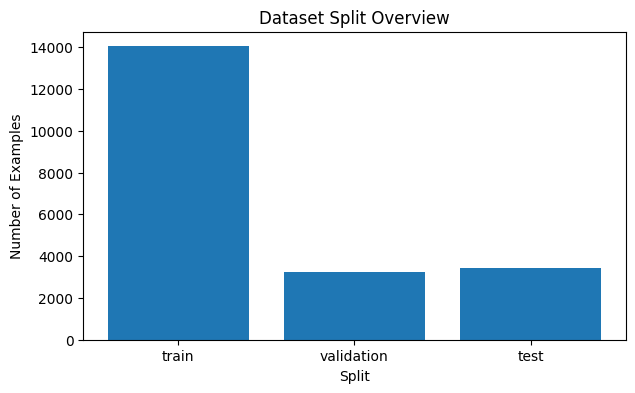

Sample Token-Level Annotation


,token,ner_tag_id,ner_label
0,EU,3,B-ORG
1,rejects,0,O
2,German,7,B-MISC
3,call,0,O
4,to,0,O
5,boycott,0,O
6,British,7,B-MISC
7,lamb,0,O
8,.,0,O


NER Label Distribution Across Splits


split,test,train,validation
label,,,
B-LOC,1668,7140,1837
B-MISC,702,3438,922
B-ORG,1661,6321,1341
B-PER,1617,6600,1842
I-LOC,257,1157,257
I-MISC,216,1155,346
I-ORG,835,3704,751
I-PER,1156,4528,1307
O,38323,169578,42759


Training Label Distribution with Percentage


,split,label,count,percentage
0,train,O,169578,83.281194
5,train,B-LOC,7140,3.506515
1,train,B-PER,6600,3.241316
3,train,B-ORG,6321,3.104297
2,train,I-PER,4528,2.223739
4,train,I-ORG,3704,1.819066
7,train,B-MISC,3438,1.688431
6,train,I-LOC,1157,0.568213
8,train,I-MISC,1155,0.567230


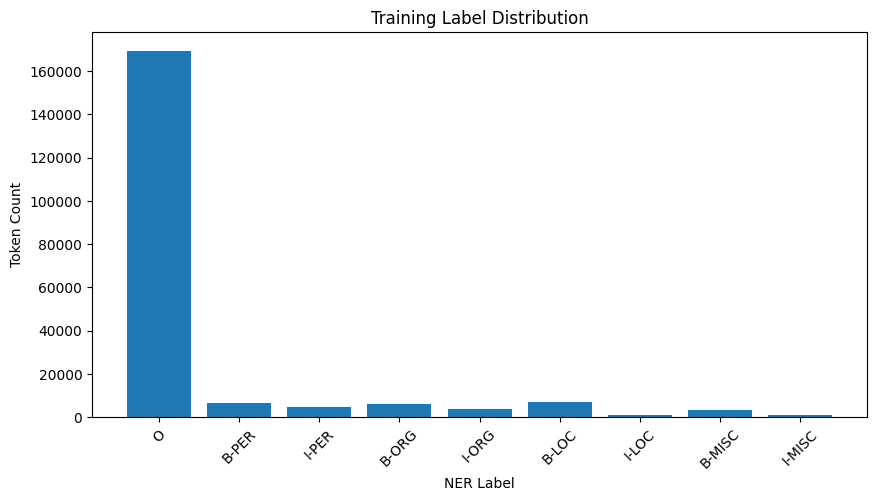

Sentence Length Summary


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,3453.0,13.447727,11.552513,1.0,5.0,9.0,20.0,124.0
train,14041.0,14.501887,11.602756,1.0,6.0,10.0,22.0,113.0
validation,3250.0,15.803692,12.603389,1.0,7.0,11.0,24.0,109.0


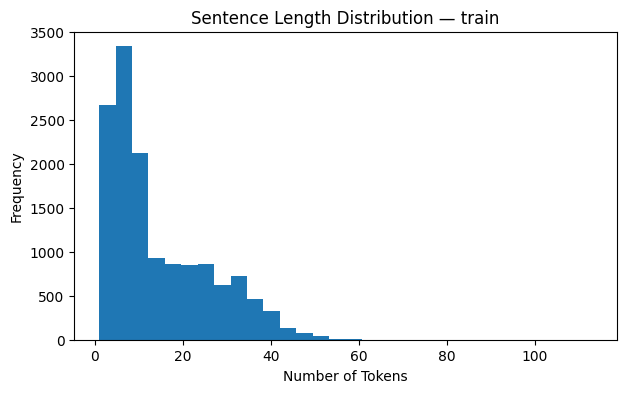

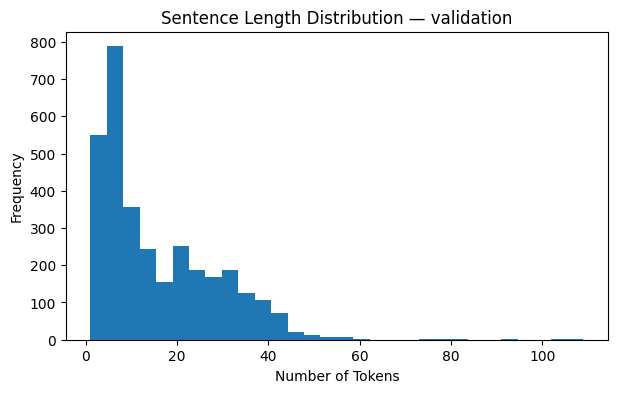

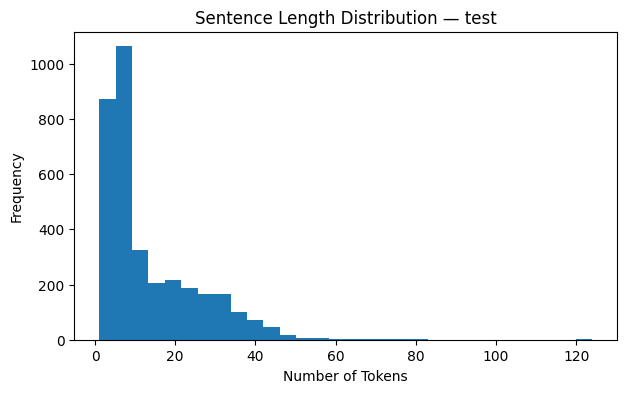

In [ ]:
# Cell 06 — Exploratory Data Analysis
# Komentar akademik:
# EDA dilakukan untuk memahami struktur awal data, distribusi label,
# dan karakteristik panjang kalimat sebelum model dilatih.
# Tahap ini penting agar keputusan modeling tidak dibuat berdasarkan asumsi.

def count_labels(dataset_split):
    counts = {label: 0 for label in label_names}

    for row in dataset_split:
        for tag_id in row["ner_tags"]:
            counts[id2label[int(tag_id)]] += 1

    return counts


# 1. Ringkasan ukuran setiap split
split_size_df = pd.DataFrame({
    "split": list(raw_datasets.keys()),
    "num_examples": [len(raw_datasets[s]) for s in raw_datasets.keys()]
})

print("Dataset Split Overview")
display(split_size_df)

plt.figure(figsize=(7, 4))
plt.bar(split_size_df["split"], split_size_df["num_examples"])
plt.title("Dataset Split Overview")
plt.xlabel("Split")
plt.ylabel("Number of Examples")
plt.show()


# 2. Menampilkan contoh anotasi token-level
example = raw_datasets["train"][0]

example_df = pd.DataFrame({
    "token": example["tokens"],
    "ner_tag_id": example["ner_tags"],
    "ner_label": [id2label[i] for i in example["ner_tags"]]
})

print("Sample Token-Level Annotation")
display(example_df)


# 3. Distribusi label NER pada seluruh split
label_distribution = []

for split in raw_datasets.keys():
    counts = count_labels(raw_datasets[split])

    for label, count in counts.items():
        label_distribution.append({
            "split": split,
            "label": label,
            "count": count
        })

label_dist_df = pd.DataFrame(label_distribution)

print("NER Label Distribution Across Splits")
display(
    label_dist_df
    .pivot(index="label", columns="split", values="count")
    .fillna(0)
    .astype(int)
)

train_label_counts = label_dist_df[label_dist_df["split"] == "train"].copy()
train_label_counts["percentage"] = (
    train_label_counts["count"] / train_label_counts["count"].sum() * 100
)

print("Training Label Distribution with Percentage")
display(train_label_counts.sort_values("count", ascending=False))

plt.figure(figsize=(10, 5))
plt.bar(train_label_counts["label"], train_label_counts["count"])
plt.title("Training Label Distribution")
plt.xlabel("NER Label")
plt.ylabel("Token Count")
plt.xticks(rotation=45)
plt.show()


# 4. Distribusi panjang kalimat
length_rows = []

for split in raw_datasets.keys():
    for row in raw_datasets[split]:
        length_rows.append({
            "split": split,
            "sentence_length": len(row["tokens"])
        })

length_df = pd.DataFrame(length_rows)

print("Sentence Length Summary")
display(length_df.groupby("split")["sentence_length"].describe())

for split in raw_datasets.keys():
    plt.figure(figsize=(7, 4))
    plt.hist(
        length_df[length_df["split"] == split]["sentence_length"],
        bins=30
    )
    plt.title(f"Sentence Length Distribution — {split}")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Frequency")
    plt.show()

Entity Type Distribution Across Splits


split,test,train,validation
entity_type,,,
LOC,1925,8297,2094
MISC,918,4593,1268
O,38323,169578,42759
ORG,2496,10025,2092
PER,2773,11128,3149


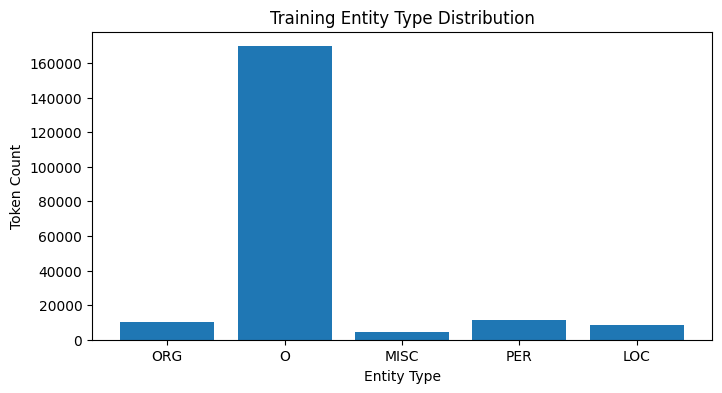

Data Bias Audit Summary


,o_to_non_o_ratio,label_imbalance_ratio,entity_type_imbalance_ratio_excluding_O,mean_sentence_length_train,max_sentence_length_train
0,4.981288,146.820779,2.422817,14.501887,113


Bias Mitigation Plan


,Bias or Risk,Mitigation Strategy,Applied
0,Dominant O label,"Use entity-level F1, per-label F1, and compare standard loss with weighted loss.",True
1,Entity type imbalance,Report per-entity metrics and inspect boundary errors.,True
2,Subword fragmentation bias,Audit token fragmentation and compare subword-label alignment strategies.,True
3,Overfitting,"Use validation monitoring, early stopping, and weight decay.",True
4,Data leakage,Select model using validation set only; evaluate test set once after selection.,True


In [ ]:
# Cell 07 — Data Bias Audit and Mitigation Plan
# Komentar akademik:
# Cell ini mengidentifikasi potensi bias data, terutama dominasi label O,
# ketidakseimbangan antar tipe entitas, dan risiko salah interpretasi accuracy.
# Hasil audit dipakai untuk menentukan mitigasi yang logis pada tahap modeling.

def entity_type_from_label(label):
    # Komentar akademik:
    # Label O dipisahkan dari tipe entitas karena O bukan named entity.
    if label == "O":
        return "O"
    return label.split("-", 1)[1]


def imbalance_ratio(counts):
    # Komentar akademik:
    # Rasio imbalance dihitung dari kelas dengan frekuensi terbesar
    # dibanding kelas dengan frekuensi terkecil yang tidak nol.
    nonzero = [c for c in counts if c > 0]

    if len(nonzero) == 0:
        return np.nan

    return max(nonzero) / max(min(nonzero), 1)


# 1. Menghitung distribusi entity type pada setiap split
entity_type_rows = []

for split in raw_datasets.keys():
    counts = {}

    for row in raw_datasets[split]:
        for tag_id in row["ner_tags"]:
            ent_type = entity_type_from_label(id2label[int(tag_id)])
            counts[ent_type] = counts.get(ent_type, 0) + 1

    for ent_type, count in counts.items():
        entity_type_rows.append({
            "split": split,
            "entity_type": ent_type,
            "count": count
        })

entity_type_df = pd.DataFrame(entity_type_rows)

print("Entity Type Distribution Across Splits")
display(
    entity_type_df
    .pivot(index="entity_type", columns="split", values="count")
    .fillna(0)
    .astype(int)
)


# 2. Visualisasi distribusi entity type pada train set
train_entity_type = entity_type_df[entity_type_df["split"] == "train"].copy()

plt.figure(figsize=(8, 4))
plt.bar(train_entity_type["entity_type"], train_entity_type["count"])
plt.title("Training Entity Type Distribution")
plt.xlabel("Entity Type")
plt.ylabel("Token Count")
plt.show()


# 3. Mengukur dominasi label O terhadap label non-O
o_count = train_label_counts.loc[
    train_label_counts["label"] == "O",
    "count"
].iloc[0]

non_o_count = train_label_counts.loc[
    train_label_counts["label"] != "O",
    "count"
].sum()

o_ratio = o_count / max(non_o_count, 1)


# 4. Mengukur imbalance antar label dan antar entity type
entity_counts_train = (
    train_entity_type[train_entity_type["entity_type"] != "O"]["count"]
    .tolist()
)

label_counts_train = train_label_counts["count"].tolist()

bias_report = {
    "o_to_non_o_ratio": float(o_ratio),
    "label_imbalance_ratio": float(imbalance_ratio(label_counts_train)),
    "entity_type_imbalance_ratio_excluding_O": float(
        imbalance_ratio(entity_counts_train)
    ),
    "mean_sentence_length_train": float(
        length_df[length_df["split"] == "train"]["sentence_length"].mean()
    ),
    "max_sentence_length_train": int(
        length_df[length_df["split"] == "train"]["sentence_length"].max()
    ),
}

print("Data Bias Audit Summary")
display(pd.DataFrame([bias_report]))


# 5. Rencana mitigasi bias dan risiko metodologis
mitigation_plan = pd.DataFrame([
    {
        "Bias or Risk": "Dominant O label",
        "Mitigation Strategy": (
            "Use entity-level F1, per-label F1, and compare standard loss "
            "with weighted loss."
        ),
        "Applied": True
    },
    {
        "Bias or Risk": "Entity type imbalance",
        "Mitigation Strategy": (
            "Report per-entity metrics and inspect boundary errors."
        ),
        "Applied": True
    },
    {
        "Bias or Risk": "Subword fragmentation bias",
        "Mitigation Strategy": (
            "Audit token fragmentation and compare subword-label alignment strategies."
        ),
        "Applied": True
    },
    {
        "Bias or Risk": "Overfitting",
        "Mitigation Strategy": (
            "Use validation monitoring, early stopping, and weight decay."
        ),
        "Applied": True
    },
    {
        "Bias or Risk": "Data leakage",
        "Mitigation Strategy": (
            "Select model using validation set only; evaluate test set once after selection."
        ),
        "Applied": True
    },
])

print("Bias Mitigation Plan")
display(mitigation_plan)


# 6. Simpan hasil audit bias ke file agar reproducible
with open(SAVE_DIR / "bias_report.json", "w", encoding="utf-8") as f:
    json.dump(bias_report, f, indent=2, ensure_ascii=False)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Subword Fragmentation Audit


,sample_size,total_words,valid_subtokens,subtoken_per_word_ratio,split_word_rate,model
0,500,7184,9782,1.361637,0.181097,distilbert-base-cased


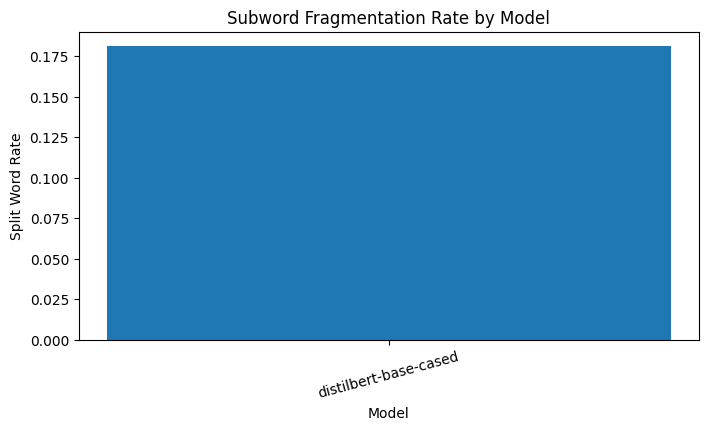

In [ ]:
# Cell 08 — Tokenizer, Subword Alignment, and Tokenized Dataset Cache
# Komentar akademik:
# Pada NER, label berada pada level kata, sedangkan tokenizer Transformer
# dapat memecah satu kata menjadi beberapa subword.
# Oleh karena itu, label harus disejajarkan secara eksplisit dengan token hasil tokenizer.

def get_tokenizer(model_name):
    # Komentar akademik:
    # RoBERTa memerlukan add_prefix_space=True ketika input sudah berupa daftar token/kata.
    # Tokenizer harus fast karena word_ids() diperlukan untuk alignment kata-subword.
    tok_kwargs = {"add_prefix_space": True} if "roberta" in model_name.lower() else {}

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        **tok_kwargs
    )

    if not tokenizer.is_fast:
        raise ValueError(
            "Tokenizer harus bertipe fast agar mendukung word_ids(). "
            "Gunakan tokenizer fast dari Hugging Face."
        )

    return tokenizer


def tokenize_and_align_labels(examples, tokenizer, label_all_tokens=False):
    # Komentar akademik:
    # Fungsi ini menyelaraskan label NER pada level kata dengan token/subword.
    # Special token seperti [CLS], [SEP], dan padding diberi label -100
    # agar tidak dihitung dalam loss.

    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    aligned_labels = []

    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:

            # Special token tidak ikut dihitung dalam loss.
            if word_idx is None:
                label_ids.append(-100)

            # Token pertama dari sebuah kata menerima label asli.
            elif word_idx != previous_word_idx:
                label_ids.append(labels[word_idx])

            # Subword lanjutan ditangani sesuai strategi alignment.
            else:
                if label_all_tokens:
                    label_id = labels[word_idx]
                    label_name = id2label[int(label_id)]

                    # Jika subword lanjutan berasal dari label B-XXX,
                    # maka secara BIO lebih konsisten jika diubah menjadi I-XXX.
                    if label_name.startswith("B-"):
                        inside_label = "I-" + label_name.split("-", 1)[1]
                        label_id = label2id.get(inside_label, label_id)

                    label_ids.append(label_id)

                else:
                    # Strategi strict_first_subword:
                    # hanya subword pertama yang diberi label,
                    # sedangkan subword lanjutan diabaikan dari loss.
                    label_ids.append(-100)

            previous_word_idx = word_idx

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels

    return tokenized_inputs


def audit_subword_fragmentation(dataset_split, tokenizer, n=500):
    # Komentar akademik:
    # Audit ini mengukur seberapa sering kata dipecah menjadi beberapa subword.
    # Jika split_word_rate tinggi, strategi alignment menjadi semakin penting.

    n = min(n, len(dataset_split))

    total_words = 0
    total_valid_subtokens = 0
    split_words = 0

    for row in dataset_split.select(range(n)):
        tokens = row["tokens"]

        enc = tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True
        )

        word_ids = [
            wid
            for wid in enc.word_ids()
            if wid is not None
        ]

        total_words += len(tokens)
        total_valid_subtokens += len(word_ids)

        for wid in set(word_ids):
            if word_ids.count(wid) > 1:
                split_words += 1

    return {
        "sample_size": n,
        "total_words": total_words,
        "valid_subtokens": total_valid_subtokens,
        "subtoken_per_word_ratio": total_valid_subtokens / max(total_words, 1),
        "split_word_rate": split_words / max(total_words, 1),
    }


def maybe_select(dataset_split, max_samples):
    # Komentar akademik:
    # FAST_RUN memakai subset data agar pipeline dapat diuji lebih cepat.
    # Untuk eksperimen final, MAX_TRAIN_SAMPLES dan MAX_EVAL_SAMPLES bernilai None.
    if max_samples is None:
        return dataset_split

    return dataset_split.select(
        range(min(max_samples, len(dataset_split)))
    )


def safe_cache_name(model_name, alignment_name, label_all_tokens):
    # Komentar akademik:
    # Nama cache dibuat eksplisit agar tokenized dataset tidak tertukar antar konfigurasi.
    model_part = str(model_name).replace("/", "_").replace(":", "_")
    fast_part = "fast" if FAST_RUN else "full"
    sample_part = f"train{MAX_TRAIN_SAMPLES}_eval{MAX_EVAL_SAMPLES}"
    align_part = f"{alignment_name}_alltok{int(label_all_tokens)}"

    return f"{model_part}__{align_part}__{fast_part}__{sample_part}"


def prepare_tokenized_dataset(
    tokenizer,
    label_all_tokens,
    model_name=None,
    alignment_name=None,
    force_retokenize=False
):
    # Komentar akademik:
    # Tokenized dataset disimpan ke disk agar proses map/tokenisasi tidak berulang.
    # Jika cache sudah ada, program langsung memuatnya dari disk.

    model_name = model_name or getattr(
        tokenizer,
        "name_or_path",
        "unknown_model"
    )

    alignment_name = alignment_name or (
        "all_subtokens" if label_all_tokens else "strict_first_subword"
    )

    cache_path = TOKENIZED_CACHE_DIR / safe_cache_name(
        model_name,
        alignment_name,
        label_all_tokens
    )

    if (not force_retokenize) and cache_path.exists():
        print(f"Tokenized Dataset Source: Local Disk Cache — {cache_path}")
        return load_from_disk(str(cache_path))

    print(f"Tokenized Dataset Source: New Tokenization — {cache_path}")

    selected = {
        "train": maybe_select(raw_datasets["train"], MAX_TRAIN_SAMPLES),
        "validation": maybe_select(raw_datasets["validation"], MAX_EVAL_SAMPLES),
        "test": maybe_select(raw_datasets["test"], MAX_EVAL_SAMPLES),
    }

    tokenized = {}

    for split, ds in selected.items():
        tokenized[split] = ds.map(
            lambda examples: tokenize_and_align_labels(
                examples,
                tokenizer=tokenizer,
                label_all_tokens=label_all_tokens
            ),
            batched=True,
            remove_columns=raw_datasets["train"].column_names,
            desc=f"Tokenizing {split} | {model_name} | {alignment_name}"
        )

    tokenized_dataset = DatasetDict(tokenized)
    tokenized_dataset.save_to_disk(str(cache_path))

    print(f"Tokenized Dataset Saved To: {cache_path}")

    return tokenized_dataset


# Audit fragmentasi subword untuk setiap model kandidat
fragmentation_rows = []

for model_name in MODEL_CANDIDATES:
    tokenizer = get_tokenizer(model_name)

    audit = audit_subword_fragmentation(
        raw_datasets["train"],
        tokenizer,
        n=500
    )

    audit["model"] = model_name
    fragmentation_rows.append(audit)

fragmentation_df = pd.DataFrame(fragmentation_rows)

print("Subword Fragmentation Audit")
display(fragmentation_df)

plt.figure(figsize=(8, 4))
plt.bar(
    fragmentation_df["model"],
    fragmentation_df["split_word_rate"]
)
plt.title("Subword Fragmentation Rate by Model")
plt.xlabel("Model")
plt.ylabel("Split Word Rate")
plt.xticks(rotation=15)
plt.show()

In [ ]:
# Cell 09 — Evaluation Metrics and BIO Repair
# Komentar akademik:
# Evaluasi utama pada NER menggunakan entity-level precision, recall, dan F1.
# Accuracy tetap dihitung, tetapi tidak digunakan sebagai dasar utama kesimpulan
# karena label O biasanya dominan dalam dataset NER.

seqeval_metric = evaluate.load("seqeval")


def repair_bio_sequence(seq):
    # Komentar akademik:
    # Fungsi ini memperbaiki inkonsistensi BIO pada prediksi model.
    # Contoh: I-ORG yang muncul setelah O diubah menjadi B-ORG.
    # Perbaikan ini hanya diterapkan pada prediksi, bukan pada gold label.

    repaired = []
    prev_type = None
    prev_prefix = "O"

    for tag in seq:

        if tag == "O":
            repaired.append(tag)
            prev_type = None
            prev_prefix = "O"
            continue

        if "-" not in tag:
            repaired.append(tag)
            prev_type = None
            prev_prefix = tag
            continue

        prefix, ent_type = tag.split("-", 1)

        # Jika I-XXX muncul setelah O atau setelah tipe entitas berbeda,
        # maka secara logika BIO ia harus menjadi B-XXX.
        if prefix == "I" and (
            prev_prefix == "O" or prev_type != ent_type
        ):
            tag = "B-" + ent_type
            prefix = "B"

        repaired.append(tag)
        prev_type = ent_type
        prev_prefix = prefix

    return repaired


def decode_predictions(logits, labels, apply_bio_repair=False):
    # Komentar akademik:
    # Fungsi ini mengubah output logits menjadi label string.
    # Label -100 diabaikan karena merepresentasikan special token,
    # padding, atau subword yang tidak dievaluasi.

    predictions = np.argmax(logits, axis=-1)

    true_predictions = []
    true_labels = []

    for prediction, label in zip(predictions, labels):

        pred_seq = []
        label_seq = []

        for pred_id, label_id in zip(prediction, label):

            if label_id != -100:
                pred_seq.append(id2label[int(pred_id)])
                label_seq.append(id2label[int(label_id)])

        if apply_bio_repair:
            pred_seq = repair_bio_sequence(pred_seq)

        true_predictions.append(pred_seq)
        true_labels.append(label_seq)

    return true_predictions, true_labels


def compute_metrics(eval_pred):
    # Komentar akademik:
    # Fungsi ini dipanggil oleh Trainer pada tahap evaluasi.
    # Dua jenis hasil dilaporkan:
    # 1. raw prediction,
    # 2. BIO-repaired prediction.
    # Keduanya ditampilkan agar evaluasi transparan dan tidak manipulatif.

    logits, labels = eval_pred

    raw_predictions, true_labels = decode_predictions(
        logits,
        labels,
        apply_bio_repair=False
    )

    repaired_predictions, _ = decode_predictions(
        logits,
        labels,
        apply_bio_repair=True
    )

    raw = seqeval_metric.compute(
        predictions=raw_predictions,
        references=true_labels
    )

    repaired = seqeval_metric.compute(
        predictions=repaired_predictions,
        references=true_labels
    )

    return {
        "precision": raw["overall_precision"],
        "recall": raw["overall_recall"],
        "f1": raw["overall_f1"],
        "accuracy": raw["overall_accuracy"],

        "repaired_precision": repaired["overall_precision"],
        "repaired_recall": repaired["overall_recall"],
        "repaired_f1": repaired["overall_f1"],
        "repaired_accuracy": repaired["overall_accuracy"],
    }

In [ ]:
# Cell 10 — Class Weighting, Trainer, and Training Arguments
# Komentar akademik:
# Cell ini mendefinisikan class weighting, custom Trainer, dan TrainingArguments.
# Weighted loss digunakan sebagai teknik mitigasi class imbalance,
# tetapi tidak diasumsikan otomatis lebih baik daripada standard loss.
# Pemilihan tetap dilakukan berdasarkan validation F1.

def compute_class_weights_from_tokenized(
    tokenized_train,
    num_labels,
    min_weight=0.2,
    max_weight=5.0
):
    # Komentar akademik:
    # Bobot kelas dihitung dari frekuensi label setelah tokenisasi.
    # Label -100 diabaikan karena tidak ikut dihitung dalam loss.
    # Bobot kemudian dinormalisasi dan dibatasi agar tidak terlalu ekstrem.

    counts = np.zeros(num_labels, dtype=np.float64)

    for row in tokenized_train:
        for label_id in row["labels"]:
            if label_id != -100:
                counts[int(label_id)] += 1

    total = counts.sum()

    weights = total / np.maximum(counts, 1.0)
    weights = weights / np.mean(weights)
    weights = np.clip(weights, min_weight, max_weight)

    weight_df = pd.DataFrame({
        "label": [id2label[i] for i in range(num_labels)],
        "count": counts.astype(int),
        "class_weight": weights
    })

    return torch.tensor(weights, dtype=torch.float), weight_df


class WeightedLossTrainer(Trainer):
    # Komentar akademik:
    # Class ini memperluas Hugging Face Trainer agar dapat memakai weighted loss.
    # Jika class_weights=None, maka model memakai loss standar dari Transformers.

    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        # Komentar akademik:
        # compute_loss menerima logits dan labels.
        # CrossEntropyLoss digunakan karena token classification adalah klasifikasi multi-kelas.
        # ignore_index=-100 memastikan special token, padding, dan subword yang diabaikan
        # tidak ikut berkontribusi pada loss.

        labels = inputs.get("labels")
        outputs = model(**inputs)

        logits = outputs.get("logits") if isinstance(outputs, dict) else outputs.logits

        if self.class_weights is None:
            loss = outputs.loss
        else:
            weights = self.class_weights.to(logits.device)

            loss_fct = nn.CrossEntropyLoss(
                weight=weights,
                ignore_index=-100
            )

            loss = loss_fct(
                logits.view(-1, model.config.num_labels),
                labels.view(-1)
            )

        return (loss, outputs) if return_outputs else loss


def make_training_args(output_dir):
    # Komentar akademik:
    # TrainingArguments mengontrol konfigurasi pelatihan.
    # load_best_model_at_end=True dan metric_for_best_model memastikan model terbaik
    # dipilih berdasarkan metrik validasi, bukan test set.

    params = {
        "output_dir": str(output_dir),
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "num_train_epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "save_strategy": "epoch",
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_repaired_f1",
        "greater_is_better": True,
        "logging_strategy": "steps",
        "logging_steps": 25,
        "report_to": "none",
        "seed": SEED,
        "data_seed": SEED,
        "fp16": torch.cuda.is_available(),
    }

    # Komentar akademik:
    # Beberapa versi Transformers memakai eval_strategy,
    # sedangkan versi lain masih memakai evaluation_strategy.
    # Pemeriksaan signature ini menjaga kompatibilitas lintas versi.
    signature = inspect.signature(TrainingArguments.__init__).parameters

    if "eval_strategy" in signature:
        params["eval_strategy"] = "epoch"
    else:
        params["evaluation_strategy"] = "epoch"

    return TrainingArguments(**params)


Training Stage: model=distilbert-base-cased, alignment=strict_first_subword
Tokenized Dataset Source: New Tokenization — integrity_aware_ner_outputs/tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300


Tokenizing train | distilbert-base-cased | strict_first_subword:   0%|          | 0/600 [00:00<?, ? examples/s…

Tokenizing validation | distilbert-base-cased | strict_first_subword:   0%|          | 0/300 [00:00<?, ? examp…

Tokenizing test | distilbert-base-cased | strict_first_subword:   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/600 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenized Dataset Saved To: integrity_aware_ner_outputs/tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300
Class Weight Summary


,label,count,class_weight
0,O,6376,0.200000
1,B-PER,327,0.383324
2,I-PER,258,0.485840
3,B-ORG,213,0.588483
4,I-ORG,139,0.901775
5,B-LOC,404,0.310264
6,I-LOC,38,3.298600
7,B-MISC,171,0.733022
8,I-MISC,55,2.279033


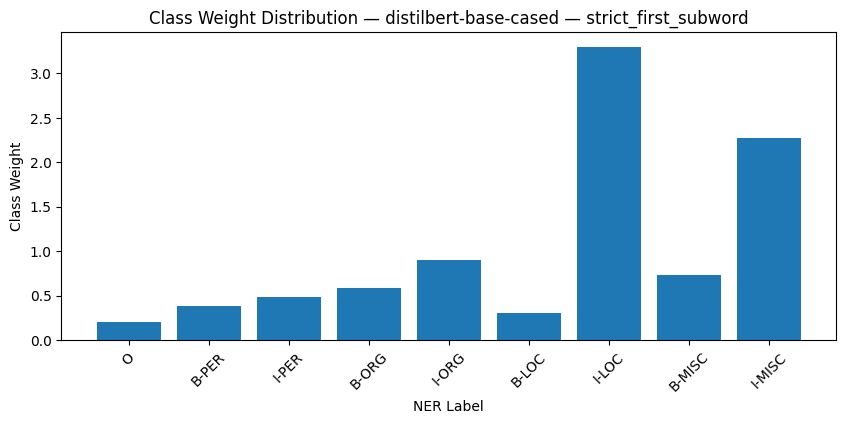


----------------------------------------------------------------------------------------------------
Experiment Run: distilbert-base-cased__strict_first_subword__standard_loss
----------------------------------------------------------------------------------------------------


model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Load Audit — distilbert-base-cased


...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Repaired Precision,Repaired Recall,Repaired F1,Repaired Accuracy
1,0.396941,0.577042,0.344954,0.352060,0.348471,0.870238,0.344954,0.352060,0.348471,0.870811
2,0.264565,0.492731,0.483402,0.436330,0.458661,0.885706,0.483402,0.436330,0.458661,0.888284


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

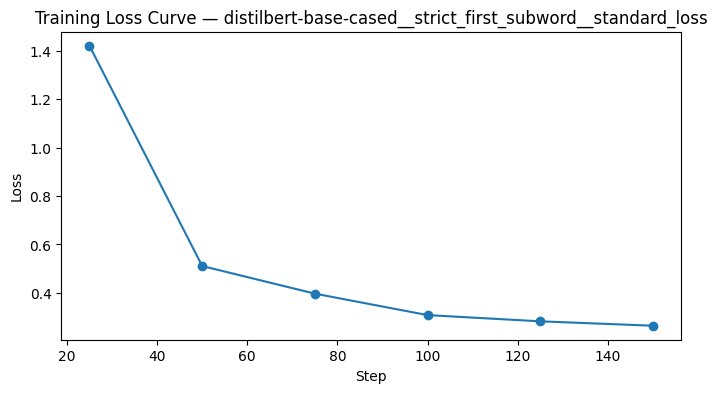

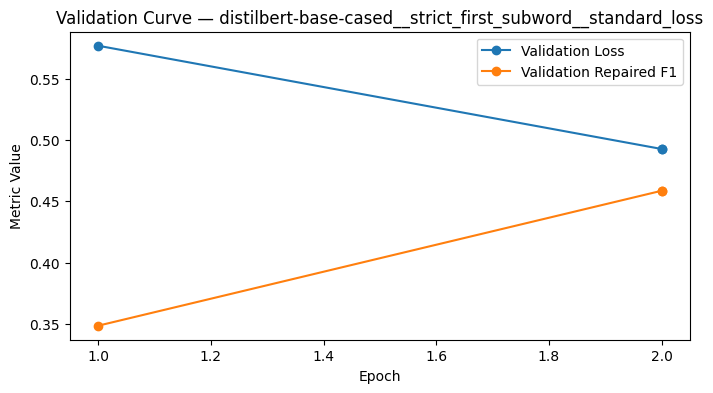


----------------------------------------------------------------------------------------------------
Experiment Run: distilbert-base-cased__strict_first_subword__weighted_loss
----------------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Load Audit — distilbert-base-cased


,key,status,interpretation
0,vocab_projector.bias,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
1,vocab_layer_norm.weight,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
2,vocab_layer_norm.bias,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
3,vocab_transform.weight,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
4,vocab_transform.bias,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
5,classifier.bias,MISSING,Allowed: token classification head is newly initialized and will be trained.
6,classifier.weight,MISSING,Allowed: token classification head is newly initialized and will be trained.


...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Repaired Precision,Repaired Recall,Repaired F1,Repaired Accuracy
1,0.850109,1.078257,0.509259,0.514981,0.512104,0.889716,0.509259,0.514981,0.512104,0.893440
2,0.555238,0.896938,0.537549,0.509363,0.523077,0.896305,0.537549,0.509363,0.523077,0.898310


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

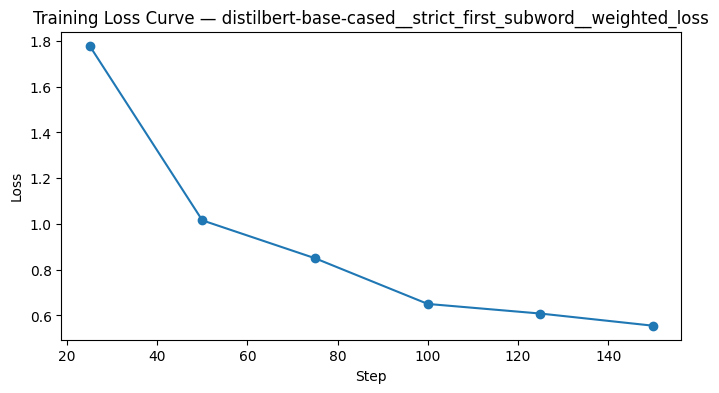

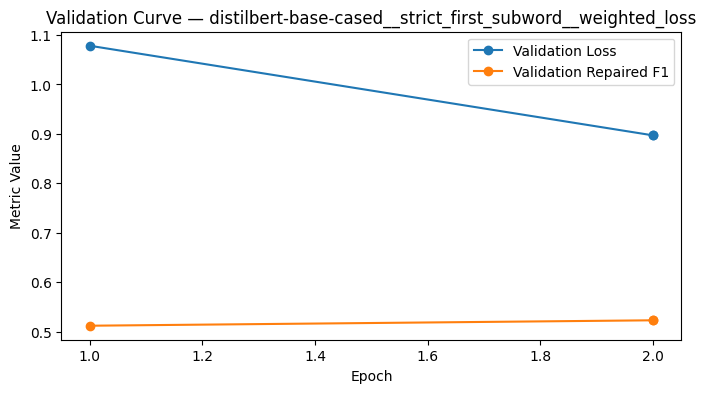


Training Stage: model=distilbert-base-cased, alignment=all_subtokens
Tokenized Dataset Source: New Tokenization — integrity_aware_ner_outputs/tokenized_cache/distilbert-base-cased__all_subtokens_alltok1__fast__train600_eval300


Tokenizing train | distilbert-base-cased | all_subtokens:   0%|          | 0/600 [00:00<?, ? examples/s]

Tokenizing validation | distilbert-base-cased | all_subtokens:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenizing test | distilbert-base-cased | all_subtokens:   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/600 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenized Dataset Saved To: integrity_aware_ner_outputs/tokenized_cache/distilbert-base-cased__all_subtokens_alltok1__fast__train600_eval300
Class Weight Summary


,label,count,class_weight
0,O,8083,0.200000
1,B-PER,327,1.009675
2,I-PER,876,0.376899
3,B-ORG,213,1.550065
4,I-ORG,466,0.708506
5,B-LOC,404,0.817237
6,I-LOC,314,1.051477
7,B-MISC,171,1.930782
8,I-MISC,218,1.514513


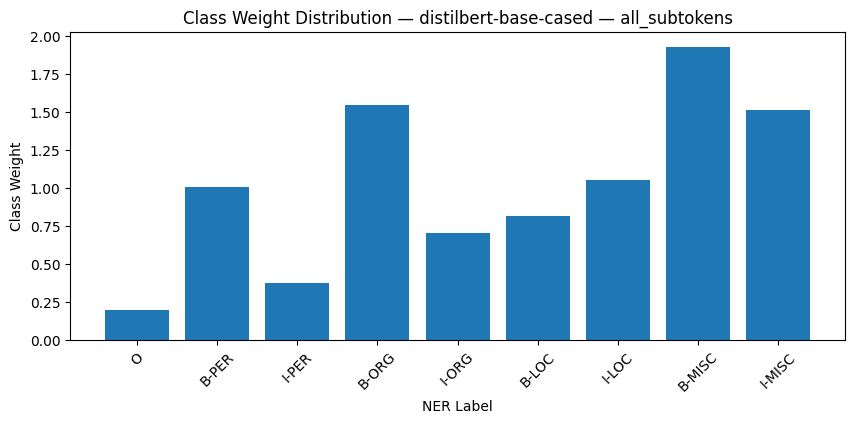


----------------------------------------------------------------------------------------------------
Experiment Run: distilbert-base-cased__all_subtokens__standard_loss
----------------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Load Audit — distilbert-base-cased


,key,status,interpretation
0,vocab_projector.bias,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
1,vocab_layer_norm.weight,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
2,vocab_layer_norm.bias,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
3,vocab_transform.weight,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
4,vocab_transform.bias,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
5,classifier.bias,MISSING,Allowed: token classification head is newly initialized and will be trained.
6,classifier.weight,MISSING,Allowed: token classification head is newly initialized and will be trained.


...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Repaired Precision,Repaired Recall,Repaired F1,Repaired Accuracy
1,0.560096,0.744735,0.367837,0.372659,0.370233,0.811113,0.367837,0.372659,0.370233,0.813236
2,0.354078,0.658598,0.478088,0.449438,0.463320,0.832915,0.478088,0.449438,0.463320,0.830214


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

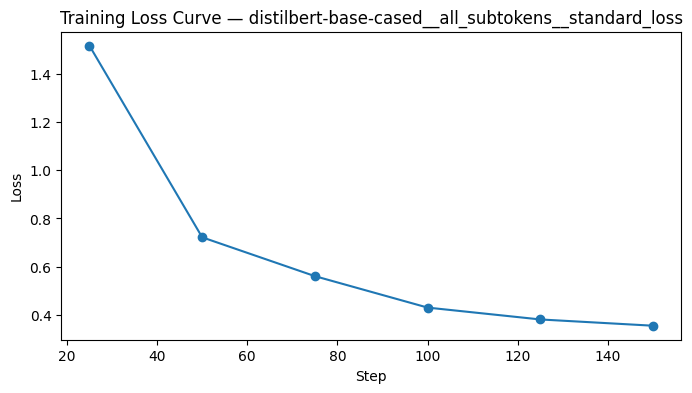

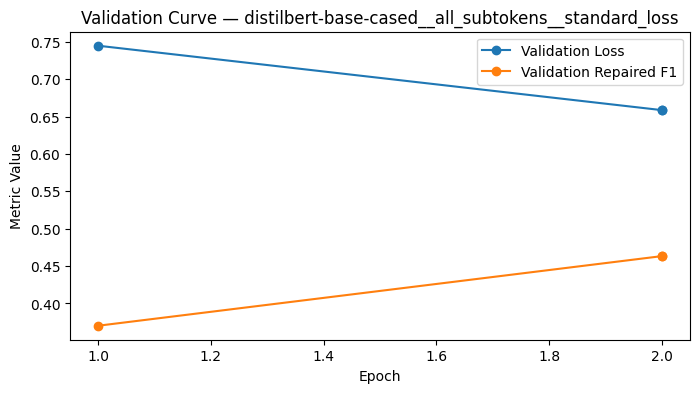


----------------------------------------------------------------------------------------------------
Experiment Run: distilbert-base-cased__all_subtokens__weighted_loss
----------------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Load Audit — distilbert-base-cased


,key,status,interpretation
0,vocab_projector.bias,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
1,vocab_layer_norm.weight,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
2,vocab_layer_norm.bias,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
3,vocab_transform.weight,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
4,vocab_transform.bias,UNEXPECTED,Allowed: pretrained task head is not used for token classification.
5,classifier.bias,MISSING,Allowed: token classification head is newly initialized and will be trained.
6,classifier.weight,MISSING,Allowed: token classification head is newly initialized and will be trained.


...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Repaired Precision,Repaired Recall,Repaired F1,Repaired Accuracy
1,1.090291,1.172067,0.257975,0.348315,0.296414,0.803203,0.257975,0.348315,0.296414,0.801466
2,0.753675,0.958265,0.366806,0.492509,0.420464,0.817480,0.366806,0.492509,0.420464,0.812271


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

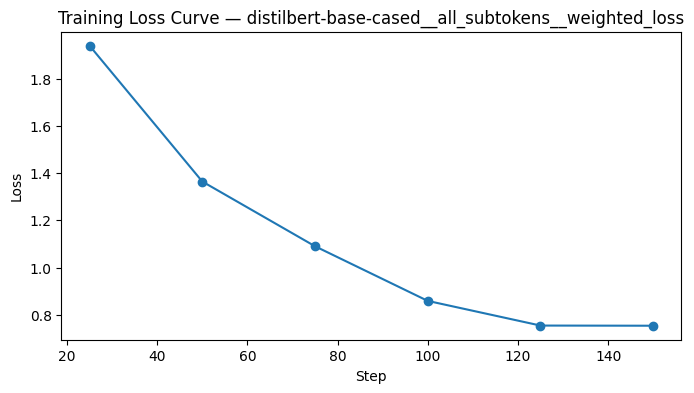

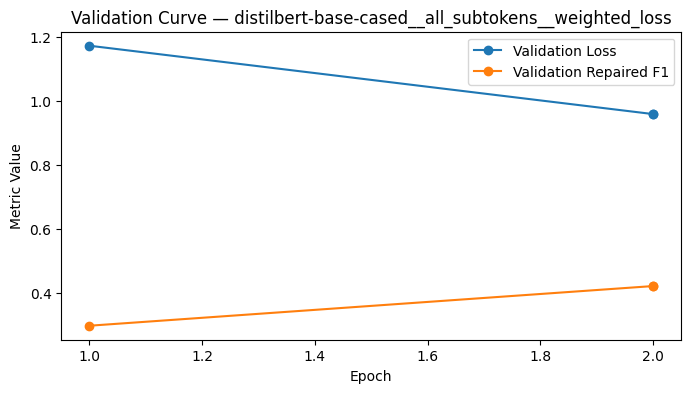

Validation Experiment Ranking


,experiment,model_name,alignment,label_all_tokens,loss_strategy,weighted_loss,output_dir,val_raw_precision,val_raw_recall,val_raw_f1,val_repaired_precision,val_repaired_recall,val_repaired_f1,val_accuracy
1,distilbert-base-cased__strict_first_subword__weighted_loss,distilbert-base-cased,strict_first_subword,False,weighted_loss,True,integrity_aware_ner_outputs/distilbert-base-cased__strict_first_subword__weighted_loss/best_model,0.537549,0.509363,0.523077,0.537549,0.509363,0.523077,0.896305
2,distilbert-base-cased__all_subtokens__standard_loss,distilbert-base-cased,all_subtokens,True,standard_loss,False,integrity_aware_ner_outputs/distilbert-base-cased__all_subtokens__standard_loss/best_model,0.478088,0.449438,0.463320,0.478088,0.449438,0.463320,0.832915
0,distilbert-base-cased__strict_first_subword__standard_loss,distilbert-base-cased,strict_first_subword,False,standard_loss,False,integrity_aware_ner_outputs/distilbert-base-cased__strict_first_subword__standard_loss/best_model,0.483402,0.436330,0.458661,0.483402,0.436330,0.458661,0.885706
3,distilbert-base-cased__all_subtokens__weighted_loss,distilbert-base-cased,all_subtokens,True,weighted_loss,True,integrity_aware_ner_outputs/distilbert-base-cased__all_subtokens__weighted_loss/best_model,0.366806,0.492509,0.420464,0.366806,0.492509,0.420464,0.817480


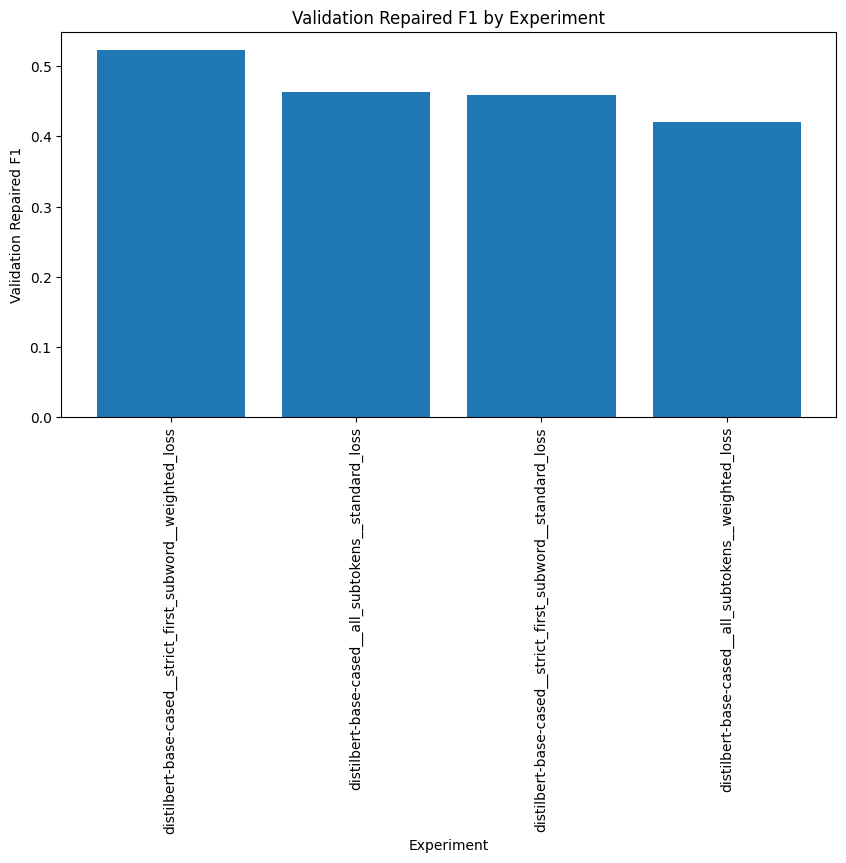

Best Validation Configuration
{
  "experiment": "distilbert-base-cased__strict_first_subword__weighted_loss",
  "model_name": "distilbert-base-cased",
  "alignment": "strict_first_subword",
  "label_all_tokens": false,
  "loss_strategy": "weighted_loss",
  "weighted_loss": true,
  "output_dir": "integrity_aware_ner_outputs/distilbert-base-cased__strict_first_subword__weighted_loss/best_model",
  "val_raw_precision": 0.5375494071146245,
  "val_raw_recall": 0.5093632958801498,
  "val_raw_f1": 0.5230769230769231,
  "val_repaired_precision": 0.5375494071146245,
  "val_repaired_recall": 0.5093632958801498,
  "val_repaired_f1": 0.5230769230769231,
  "val_accuracy": 0.8963047837295903
}


In [ ]:
# Cell 11 — Model Training and Validation-Based Selection
# Komentar akademik:
# Cell ini menjalankan training untuk setiap kombinasi:
# 1. model kandidat,
# 2. strategi subword-label alignment,
# 3. strategi loss.
#
# Revisi gabungan:
# 1. Memperbaiki error Trainer.__init__() unexpected keyword argument 'tokenizer'
#    dengan fungsi trainer_tokenizer_kwargs().
# 2. Mengubah warning missing/unexpected keys saat loading DistilBERT menjadi
#    audit model yang eksplisit dan terdokumentasi.
# 3. Model terbaik tetap dipilih berdasarkan validation repaired F1, bukan test set.

def trainer_tokenizer_kwargs(tokenizer):
    # Komentar akademik:
    # Versi Transformers berbeda dalam menerima argumen tokenizer.
    # Versi baru menggunakan processing_class.
    # Versi lama dapat menggunakan tokenizer.
    # Fungsi ini menjaga kompatibilitas lintas versi tanpa mengubah logika training.

    trainer_signature = inspect.signature(Trainer.__init__).parameters

    if "processing_class" in trainer_signature:
        return {"processing_class": tokenizer}

    if "tokenizer" in trainer_signature:
        return {"tokenizer": tokenizer}

    return {}


def load_token_classification_model_with_audit(
    model_name,
    num_labels,
    id2label,
    label2id
):
    # Komentar akademik:
    # Pretrained model seperti distilbert-base-cased awalnya bukan model NER.
    # Ketika dipakai untuk token classification, classifier head dibuat baru.
    # Karena itu, classifier.weight dan classifier.bias boleh missing.
    #
    # Sebaliknya, komponen seperti vocab_transform, vocab_projector, dan
    # vocab_layer_norm berasal dari head pretraining/masked language modeling.
    # Komponen tersebut tidak dipakai dalam token classification sehingga boleh unexpected.

    loaded = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        output_loading_info=True
    )

    if isinstance(loaded, tuple):
        model, loading_info = loaded
    else:
        model = loaded
        loading_info = {
            "missing_keys": [],
            "unexpected_keys": [],
            "mismatched_keys": [],
            "error_msgs": []
        }

    missing_keys = loading_info.get("missing_keys", [])
    unexpected_keys = loading_info.get("unexpected_keys", [])
    mismatched_keys = loading_info.get("mismatched_keys", [])
    error_msgs = loading_info.get("error_msgs", [])

    allowed_missing = {
        "classifier.weight",
        "classifier.bias"
    }

    def is_allowed_unexpected_key(key):
        # Komentar akademik:
        # Pola berikut mewakili task head lama/pretraining head yang tidak relevan
        # untuk token classification.
        allowed_prefixes = (
            "vocab_",
            "cls.",
            "predictions.",
            "pre_classifier"
        )
        return key.startswith(allowed_prefixes)

    critical_missing = [
        key for key in missing_keys
        if key not in allowed_missing
    ]

    critical_unexpected = [
        key for key in unexpected_keys
        if not is_allowed_unexpected_key(key)
    ]

    load_report_rows = []

    for key in unexpected_keys:
        load_report_rows.append({
            "key": key,
            "status": "UNEXPECTED",
            "interpretation": (
                "Allowed: pretrained task head is not used for token classification."
                if is_allowed_unexpected_key(key)
                else "Critical: unexpected key outside allowed task-head pattern."
            )
        })

    for key in missing_keys:
        load_report_rows.append({
            "key": key,
            "status": "MISSING",
            "interpretation": (
                "Allowed: token classification head is newly initialized and will be trained."
                if key in allowed_missing
                else "Critical: missing key outside classifier head."
            )
        })

    for item in mismatched_keys:
        load_report_rows.append({
            "key": str(item),
            "status": "MISMATCHED",
            "interpretation": "Inspect carefully; shape mismatch can be critical."
        })

    for msg in error_msgs:
        load_report_rows.append({
            "key": str(msg),
            "status": "ERROR_MSG",
            "interpretation": "Loading error message from Transformers."
        })

    load_report_df = pd.DataFrame(load_report_rows)

    print(f"Model Load Audit — {model_name}")
    if load_report_df.empty:
        print("No missing or unexpected keys reported.")
    else:
        display(load_report_df)

    if critical_missing or critical_unexpected or mismatched_keys or error_msgs:
        raise RuntimeError(
            "Critical model loading issue detected. "
            f"critical_missing={critical_missing}, "
            f"critical_unexpected={critical_unexpected}, "
            f"mismatched_keys={mismatched_keys}, "
            f"error_msgs={error_msgs}"
        )

    print(
        "Model Load Audit Status: PASSED — "
        "new classifier head is expected and will be trained on CoNLL-2003."
    )

    return model


def extract_log_history(log_history):
    # Komentar akademik:
    # Log history diubah menjadi DataFrame agar learning curve dapat divisualisasikan.
    return pd.DataFrame([dict(item) for item in log_history])


def plot_training_history(history_df, title_prefix=""):
    # Komentar akademik:
    # Learning curve membantu membaca indikasi underfitting dan overfitting.

    if history_df.empty:
        print("No Training History Available")
        return

    if "loss" in history_df.columns:
        train_loss_df = history_df.dropna(subset=["loss"])

        if not train_loss_df.empty:
            plt.figure(figsize=(8, 4))
            plt.plot(
                train_loss_df["step"],
                train_loss_df["loss"],
                marker="o"
            )
            plt.title(f"Training Loss Curve — {title_prefix}")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.show()

    if "eval_loss" in history_df.columns:
        eval_df = history_df.dropna(subset=["eval_loss"])

        if not eval_df.empty:
            plt.figure(figsize=(8, 4))
            plt.plot(
                eval_df["epoch"],
                eval_df["eval_loss"],
                marker="o",
                label="Validation Loss"
            )

            if "eval_repaired_f1" in eval_df.columns:
                plt.plot(
                    eval_df["epoch"],
                    eval_df["eval_repaired_f1"],
                    marker="o",
                    label="Validation Repaired F1"
                )

            plt.title(f"Validation Curve — {title_prefix}")
            plt.xlabel("Epoch")
            plt.ylabel("Metric Value")
            plt.legend()
            plt.show()


experiment_results = []
experiment_histories = {}

for model_name in MODEL_CANDIDATES:
    tokenizer = get_tokenizer(model_name)

    for align_cfg in ALIGNMENT_VARIANTS:

        print("\n" + "=" * 100)
        print(f"Training Stage: model={model_name}, alignment={align_cfg['name']}")
        print("=" * 100)

        tokenized = prepare_tokenized_dataset(
            tokenizer=tokenizer,
            label_all_tokens=align_cfg["label_all_tokens"],
            model_name=model_name,
            alignment_name=align_cfg["name"],
            force_retokenize=False
        )

        data_collator = DataCollatorForTokenClassification(
            tokenizer=tokenizer
        )

        class_weights, weight_df = compute_class_weights_from_tokenized(
            tokenized["train"],
            num_labels=len(label_names)
        )

        print("Class Weight Summary")
        display(weight_df)

        plt.figure(figsize=(10, 4))
        plt.bar(
            weight_df["label"],
            weight_df["class_weight"]
        )
        plt.title(
            f"Class Weight Distribution — {model_name} — {align_cfg['name']}"
        )
        plt.xlabel("NER Label")
        plt.ylabel("Class Weight")
        plt.xticks(rotation=45)
        plt.show()

        for loss_cfg in LOSS_VARIANTS:
            set_all_seeds(SEED)

            exp_name = (
                f"{model_name.replace('/', '_')}"
                f"__{align_cfg['name']}"
                f"__{loss_cfg['name']}"
            )

            output_dir = SAVE_DIR / exp_name
            output_dir.mkdir(exist_ok=True, parents=True)

            print("\n" + "-" * 100)
            print(f"Experiment Run: {exp_name}")
            print("-" * 100)

            model = load_token_classification_model_with_audit(
                model_name=model_name,
                num_labels=len(label_names),
                id2label=id2label,
                label2id=label2id
            )

            training_args = make_training_args(output_dir)

            trainer = WeightedLossTrainer(
                model=model,
                args=training_args,
                train_dataset=tokenized["train"],
                eval_dataset=tokenized["validation"],
                data_collator=data_collator,
                compute_metrics=compute_metrics,
                class_weights=class_weights if loss_cfg["weighted"] else None,
                callbacks=[
                    EarlyStoppingCallback(
                        early_stopping_patience=EARLY_STOPPING_PATIENCE
                    )
                ],
                **trainer_tokenizer_kwargs(tokenizer)
            )

            trainer.train()
            val_metrics = trainer.evaluate()

            model_dir = output_dir / "best_model"
            trainer.save_model(model_dir)
            tokenizer.save_pretrained(model_dir)

            history_df = extract_log_history(
                trainer.state.log_history
            )

            history_df.to_csv(
                output_dir / "training_history.csv",
                index=False
            )

            row = {
                "experiment": exp_name,
                "model_name": model_name,
                "alignment": align_cfg["name"],
                "label_all_tokens": align_cfg["label_all_tokens"],
                "loss_strategy": loss_cfg["name"],
                "weighted_loss": loss_cfg["weighted"],
                "output_dir": str(model_dir),

                "val_raw_precision": val_metrics.get("eval_precision"),
                "val_raw_recall": val_metrics.get("eval_recall"),
                "val_raw_f1": val_metrics.get("eval_f1"),

                "val_repaired_precision": val_metrics.get(
                    "eval_repaired_precision"
                ),
                "val_repaired_recall": val_metrics.get(
                    "eval_repaired_recall"
                ),
                "val_repaired_f1": val_metrics.get(
                    "eval_repaired_f1"
                ),

                "val_accuracy": val_metrics.get("eval_accuracy"),
            }

            experiment_results.append(row)
            experiment_histories[exp_name] = history_df

            plot_training_history(
                history_df,
                title_prefix=exp_name
            )

            del trainer, model

            if torch.cuda.is_available():
                torch.cuda.empty_cache()


results_df = (
    pd.DataFrame(experiment_results)
    .sort_values("val_repaired_f1", ascending=False)
)

print("Validation Experiment Ranking")
display(results_df)

results_df.to_csv(
    SAVE_DIR / "validation_experiment_results.csv",
    index=False
)

plt.figure(figsize=(10, 5))
plt.bar(
    results_df["experiment"],
    results_df["val_repaired_f1"]
)
plt.title("Validation Repaired F1 by Experiment")
plt.xlabel("Experiment")
plt.ylabel("Validation Repaired F1")
plt.xticks(rotation=90)
plt.show()

best_config = results_df.iloc[0].to_dict()

print("Best Validation Configuration")
print(json.dumps(best_config, indent=2))

In [12]:
# Cell 12 — Fit Diagnosis
# Komentar akademik:
# Cell ini membaca log training dari Cell 11 untuk mendeteksi indikasi awal
# underfitting dan overfitting. Diagnosis ini bersifat heuristik, sehingga
# harus dibaca bersama grafik Training Loss Curve dan Validation Curve.

def diagnose_fit(history_df):
    # Komentar akademik:
    # Fungsi ini tidak menggantikan evaluasi ilmiah penuh.
    # Ia hanya memberi sinyal awal berdasarkan perubahan validation loss
    # dan validation repaired F1.

    diagnosis = []

    if history_df.empty:
        return ["No log history available; fit diagnosis cannot be performed."]

    if "eval_loss" not in history_df.columns:
        return ["No eval_loss found in log history; validation-based fit diagnosis is limited."]

    eval_df = history_df.dropna(subset=["eval_loss"]).copy()

    if eval_df.empty:
        return ["Insufficient validation history for fit diagnosis."]

    first_eval_loss = eval_df["eval_loss"].iloc[0]
    last_eval_loss = eval_df["eval_loss"].iloc[-1]

    if "eval_repaired_f1" in eval_df.columns:
        first_f1 = eval_df["eval_repaired_f1"].iloc[0]
        last_f1 = eval_df["eval_repaired_f1"].iloc[-1]

        if last_f1 < first_f1 and last_eval_loss > first_eval_loss:
            diagnosis.append(
                "Potential overfitting: validation F1 decreased while validation loss increased."
            )

        elif last_f1 < 0.50:
            diagnosis.append(
                "Potential underfitting or insufficient FAST_RUN sample size: validation F1 remains low."
            )

        elif last_f1 >= first_f1 and last_eval_loss <= first_eval_loss:
            diagnosis.append(
                "Stable learning signal: validation F1 improved and validation loss did not increase."
            )

        else:
            diagnosis.append(
                "No strong overfitting or underfitting signal detected by this heuristic."
            )

    else:
        if last_eval_loss > first_eval_loss:
            diagnosis.append(
                "Validation loss increased; inspect possible overfitting."
            )
        else:
            diagnosis.append(
                "Validation loss did not increase; no strong overfitting signal detected."
            )

    return diagnosis


diagnosis_rows = []

for exp_name, hist_df in experiment_histories.items():
    for d in diagnose_fit(hist_df):
        diagnosis_rows.append({
            "experiment": exp_name,
            "diagnosis": d
        })

diagnosis_df = pd.DataFrame(diagnosis_rows)

print("Fit Diagnosis Summary")
display(diagnosis_df)

diagnosis_df.to_csv(
    SAVE_DIR / "fit_diagnosis.csv",
    index=False
)

Fit Diagnosis Summary


,experiment,diagnosis
0,distilbert-base-cased__strict_first_subword__standard_loss,Potential underfitting or insufficient FAST_RUN sample size: validation F1 remains low.
1,distilbert-base-cased__strict_first_subword__weighted_loss,Stable learning signal: validation F1 improved and validation loss did not increase.
2,distilbert-base-cased__all_subtokens__standard_loss,Potential underfitting or insufficient FAST_RUN sample size: validation F1 remains low.
3,distilbert-base-cased__all_subtokens__weighted_loss,Potential underfitting or insufficient FAST_RUN sample size: validation F1 remains low.


Final Evaluation Configuration
Best Model: distilbert-base-cased
Best Alignment: strict_first_subword
Best Loss Strategy: weighted_loss
Best Model Directory: integrity_aware_ner_outputs/distilbert-base-cased__strict_first_subword__weighted_loss/best_model
Tokenized Dataset Source: Local Disk Cache — integrity_aware_ner_outputs/tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Final Test Metrics


,eval_loss,eval_model_preparation_time,eval_precision,eval_recall,eval_f1,eval_accuracy,eval_repaired_precision,eval_repaired_recall,eval_repaired_f1,eval_repaired_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.359079,0.0064,0.674581,0.71875,0.695965,0.927543,0.674581,0.71875,0.695965,0.934739,1.5607,192.227,24.349


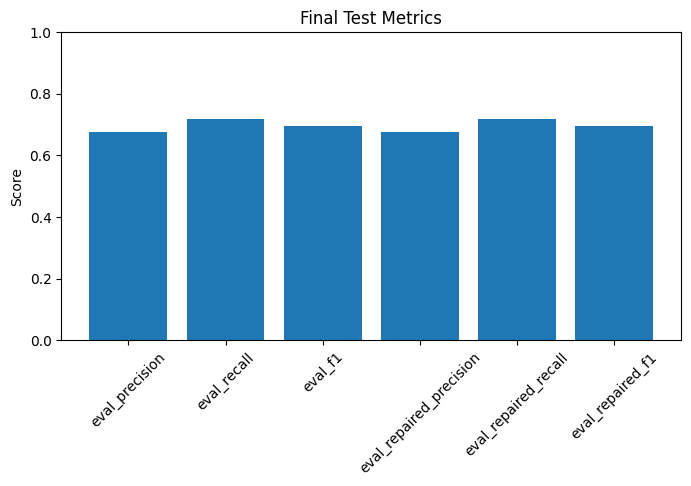

In [13]:
# Cell 13 — Final Test Evaluation
# Komentar akademik:
# Cell ini melakukan evaluasi final pada test set.
# Test set hanya digunakan setelah model terbaik dipilih berdasarkan validation set.
# Prinsip ini penting untuk mencegah data leakage dan menjaga integritas hasil penelitian.

# Validasi awal: pastikan best_config sudah tersedia dari Cell 11.
if "best_config" not in globals():
    raise RuntimeError(
        "best_config belum tersedia. Jalankan Cell 11 terlebih dahulu "
        "sampai proses training dan validation-based selection selesai."
    )

best_model_name = best_config["model_name"]
best_alignment = best_config["alignment"]
best_label_all_tokens = bool(best_config["label_all_tokens"])
best_loss_strategy = best_config["loss_strategy"]
best_model_dir = best_config["output_dir"]

print("Final Evaluation Configuration")
print("Best Model:", best_model_name)
print("Best Alignment:", best_alignment)
print("Best Loss Strategy:", best_loss_strategy)
print("Best Model Directory:", best_model_dir)

# Komentar akademik:
# Tokenizer dan tokenized dataset harus menggunakan strategi alignment yang sama
# dengan konfigurasi terbaik hasil validation.
tokenizer = get_tokenizer(best_model_name)

tokenized = prepare_tokenized_dataset(
    tokenizer=tokenizer,
    label_all_tokens=best_label_all_tokens,
    model_name=best_model_name,
    alignment_name=best_alignment,
    force_retokenize=False
)

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

# Komentar akademik:
# Model terbaik dimuat dari folder best_model yang sudah disimpan pada Cell 11.
# Tahap ini tidak melakukan training ulang.
model = AutoModelForTokenClassification.from_pretrained(
    best_model_dir
)

test_args = make_training_args(
    SAVE_DIR / "final_test_evaluation"
)

# Komentar akademik:
# Sama seperti Cell 11, pemanggilan Trainer dibuat kompatibel dengan versi Transformers
# yang berbeda melalui trainer_tokenizer_kwargs().
test_trainer = Trainer(
    model=model,
    args=test_args,
    eval_dataset=tokenized["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    **trainer_tokenizer_kwargs(tokenizer)
)

# Komentar akademik:
# Evaluasi test dilakukan satu kali setelah model dipilih dari validation set.
# Hasil ini menjadi dasar pelaporan performa final.
test_metrics = test_trainer.evaluate()

test_metrics_df = pd.DataFrame([test_metrics])

print("Final Test Metrics")
display(test_metrics_df)

test_metrics_df.to_csv(
    SAVE_DIR / "final_test_metrics.csv",
    index=False
)

plt.figure(figsize=(8, 4))

metric_names = [
    "eval_precision",
    "eval_recall",
    "eval_f1",
    "eval_repaired_precision",
    "eval_repaired_recall",
    "eval_repaired_f1"
]

metric_values = [
    test_metrics.get(m, np.nan)
    for m in metric_names
]

plt.bar(
    metric_names,
    metric_values
)

plt.title("Final Test Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

Raw Prediction Classification Report
              precision    recall  f1-score   support

         LOC     0.6818    0.7426    0.7109       202
        MISC     0.4762    0.3774    0.4211        53
         ORG     0.2297    0.2615    0.2446        65
         PER     0.7789    0.8409    0.8087       352

   micro avg     0.6746    0.7188    0.6960       672
   macro avg     0.5417    0.5556    0.5463       672
weighted avg     0.6727    0.7188    0.6942       672


BIO-Repaired Prediction Classification Report
              precision    recall  f1-score   support

         LOC     0.6818    0.7426    0.7109       202
        MISC     0.4762    0.3774    0.4211        53
         ORG     0.2297    0.2615    0.2446        65
         PER     0.7789    0.8409    0.8087       352

   micro avg     0.6746    0.7188    0.6960       672
   macro avg     0.5417    0.5556    0.5463       672
weighted avg     0.6727    0.7188    0.6942       672

Token-Level Confusion Matrix


,O,B-PER,I-PER,B-ORG,I-ORG,B-LOC,I-LOC,B-MISC,I-MISC
O,2981,3,0,5,0,4,0,8,4
B-PER,13,323,1,1,0,14,0,0,0
I-PER,6,27,231,0,0,0,0,0,0
B-ORG,5,15,0,30,0,14,0,1,0
I-ORG,3,2,3,4,5,8,0,0,0
B-LOC,20,8,0,19,0,154,0,0,1
I-LOC,4,2,1,4,4,12,3,2,0
B-MISC,9,0,0,10,0,9,0,25,0
I-MISC,5,0,0,1,0,5,0,6,15


<Figure size 1000x800 with 0 Axes>

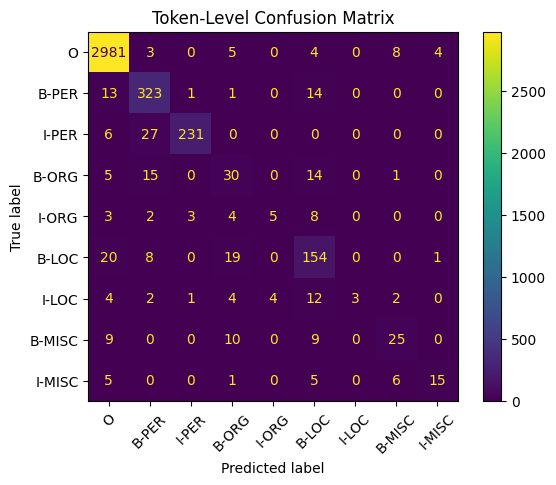

Confusion Matrix Saved To: integrity_aware_ner_outputs/token_level_confusion_matrix.csv


In [14]:
# Cell 14 — Per-Label Report and Token-Level Confusion Matrix
# Komentar akademik:
# Cell ini menampilkan laporan performa per label dan confusion matrix token-level.
# Overall F1 tidak cukup untuk memahami model NER secara detail.
# Karena itu, per-label report digunakan untuk melihat entitas mana yang lebih kuat/lemah.

# Validasi awal: pastikan test_trainer dan tokenized test sudah tersedia.
if "test_trainer" not in globals():
    raise RuntimeError(
        "test_trainer belum tersedia. Jalankan Cell 13 terlebih dahulu "
        "sampai Final Test Evaluation selesai."
    )

if "tokenized" not in globals():
    raise RuntimeError(
        "tokenized dataset belum tersedia. Jalankan Cell 13 terlebih dahulu."
    )

# Komentar akademik:
# trainer.predict() menghasilkan prediksi logits dan label_ids pada test set.
# Hasil ini kemudian didekode menjadi label string agar dapat dianalisis.
pred_output = test_trainer.predict(
    tokenized["test"]
)

logits = pred_output.predictions
labels = pred_output.label_ids

raw_pred_seqs, true_label_seqs = decode_predictions(
    logits,
    labels,
    apply_bio_repair=False
)

repaired_pred_seqs, _ = decode_predictions(
    logits,
    labels,
    apply_bio_repair=True
)

print("Raw Prediction Classification Report")
print(
    classification_report(
        true_label_seqs,
        raw_pred_seqs,
        digits=4
    )
)

print("\nBIO-Repaired Prediction Classification Report")
print(
    classification_report(
        true_label_seqs,
        repaired_pred_seqs,
        digits=4
    )
)


# Komentar akademik:
# Confusion matrix token-level bersifat pelengkap.
# Pada NER, entity-level F1 tetap menjadi metrik utama,
# tetapi confusion matrix membantu melihat pola salah prediksi antar label.
flat_true = []
flat_pred = []

for true_seq, pred_seq in zip(true_label_seqs, repaired_pred_seqs):
    for true_label, pred_label in zip(true_seq, pred_seq):
        flat_true.append(true_label)
        flat_pred.append(pred_label)

cm = confusion_matrix(
    flat_true,
    flat_pred,
    labels=label_names
)

cm_df = pd.DataFrame(
    cm,
    index=label_names,
    columns=label_names
)

print("Token-Level Confusion Matrix")
display(cm_df)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("Token-Level Confusion Matrix")
plt.show()


# Komentar akademik:
# Simpan hasil confusion matrix agar dapat digunakan dalam laporan penelitian.
CONFUSION_MATRIX_CSV = SAVE_DIR / "token_level_confusion_matrix.csv"

cm_df.to_csv(
    CONFUSION_MATRIX_CSV,
    index=True
)

print("Confusion Matrix Saved To:", CONFUSION_MATRIX_CSV)

Raw Boundary Error Summary


,error_type,count
0,gold_entities,672
1,pred_entities,716
2,exact_match,483
3,missing_entity,189
4,spurious_entity,233
5,boundary_mismatch_overlap,99
6,type_mismatch_overlap,116


BIO-Repaired Boundary Error Summary


,error_type,count
0,gold_entities,672
1,pred_entities,716
2,exact_match,483
3,missing_entity,189
4,spurious_entity,233
5,boundary_mismatch_overlap,99
6,type_mismatch_overlap,116


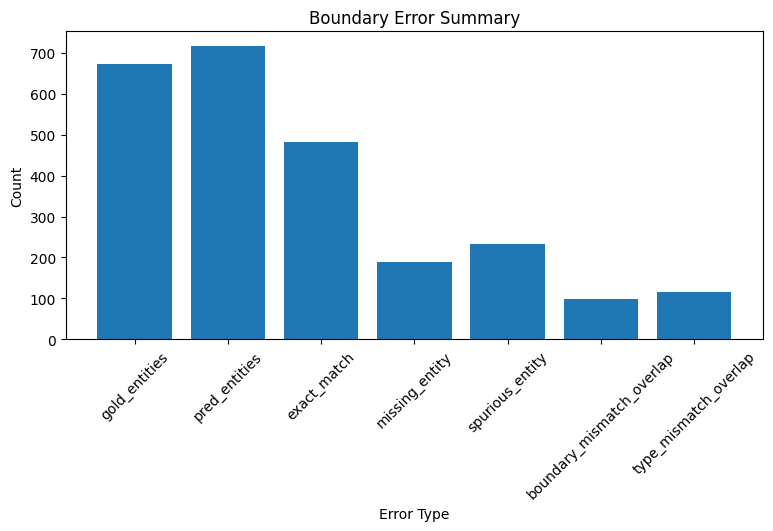

Boundary Error Files Saved
Raw Boundary Error: integrity_aware_ner_outputs/raw_boundary_error.csv
BIO-Repaired Boundary Error: integrity_aware_ner_outputs/repaired_boundary_error.csv


In [15]:
# Cell 15 — Boundary Error Analysis
# Komentar akademik:
# Cell ini menganalisis kesalahan pada level span entitas.
# Dalam NER, prediksi tidak cukup dinilai dari token benar/salah,
# tetapi juga harus dilihat apakah batas awal-akhir entitas dan tipe entitasnya benar.

# Validasi awal: pastikan sequence hasil decode dari Cell 14 sudah tersedia.
required_sequences = [
    "true_label_seqs",
    "raw_pred_seqs",
    "repaired_pred_seqs"
]

missing_sequences = [
    name
    for name in required_sequences
    if name not in globals()
]

if missing_sequences:
    raise RuntimeError(
        "Sequence prediksi belum tersedia. Jalankan Cell 14 terlebih dahulu. "
        f"Missing objects: {missing_sequences}"
    )


def bio_to_spans(seq):
    # Komentar akademik:
    # Fungsi ini mengubah urutan label BIO menjadi himpunan span entitas.
    # Format span: (start_index, end_index, entity_type).
    #
    # Contoh:
    # ["B-PER", "I-PER", "O", "B-LOC"]
    # menjadi:
    # {(0, 1, "PER"), (3, 3, "LOC")}

    spans = []
    start = None
    ent_type = None

    # Komentar akademik:
    # Token O tambahan di akhir membantu menutup entitas terakhir
    # jika sequence berakhir dengan B- atau I-.
    extended = list(seq) + ["O"]

    for i, tag in enumerate(extended):

        if tag == "O" or "-" not in tag:
            if start is not None:
                spans.append(
                    (start, i - 1, ent_type)
                )
                start = None
                ent_type = None

            continue

        prefix, current_type = tag.split("-", 1)

        if prefix == "B":
            if start is not None:
                spans.append(
                    (start, i - 1, ent_type)
                )

            start = i
            ent_type = current_type

        elif prefix == "I":
            # Komentar akademik:
            # Jika I-XXX muncul tanpa B- sebelumnya,
            # fungsi ini tetap menanganinya secara toleran sebagai awal span.
            # Ini penting untuk menganalisis prediksi model yang mungkin tidak konsisten BIO.
            if start is None:
                start = i
                ent_type = current_type

            elif current_type != ent_type:
                spans.append(
                    (start, i - 1, ent_type)
                )
                start = i
                ent_type = current_type

    return set(spans)


def overlap(span_a, span_b):
    # Komentar akademik:
    # Dua span dianggap overlap jika rentang tokennya saling beririsan.
    a_start, a_end, _ = span_a
    b_start, b_end, _ = span_b

    return max(a_start, b_start) <= min(a_end, b_end)


def boundary_error_summary(true_sequences, pred_sequences):
    # Komentar akademik:
    # Fungsi ini menghitung ringkasan error span:
    # 1. exact_match,
    # 2. missing_entity,
    # 3. spurious_entity,
    # 4. boundary_mismatch_overlap,
    # 5. type_mismatch_overlap.
    #
    # exact_match berarti start, end, dan entity_type sama.
    # boundary_mismatch_overlap berarti prediksi overlap dengan gold dan tipe sama,
    # tetapi batas span tidak identik.
    # type_mismatch_overlap berarti prediksi overlap dengan gold tetapi tipe entitas berbeda.

    rows = []

    for true_seq, pred_seq in zip(true_sequences, pred_sequences):

        gold = bio_to_spans(true_seq)
        pred = bio_to_spans(pred_seq)

        exact = gold & pred
        missing = gold - pred
        spurious = pred - gold

        boundary_mismatch = 0
        type_mismatch = 0

        for gold_span in missing:
            for pred_span in spurious:
                if overlap(gold_span, pred_span):

                    if gold_span[2] == pred_span[2]:
                        boundary_mismatch += 1

                    else:
                        type_mismatch += 1

        rows.append({
            "gold_entities": len(gold),
            "pred_entities": len(pred),
            "exact_match": len(exact),
            "missing_entity": len(missing),
            "spurious_entity": len(spurious),
            "boundary_mismatch_overlap": boundary_mismatch,
            "type_mismatch_overlap": type_mismatch,
        })

    return (
        pd.DataFrame(rows)
        .sum()
        .to_frame("count")
        .reset_index()
        .rename(columns={"index": "error_type"})
    )


# Komentar akademik:
# Boundary error dihitung untuk raw prediction dan BIO-repaired prediction
# agar pengaruh post-processing dapat dibaca secara transparan.
raw_boundary_df = boundary_error_summary(
    true_label_seqs,
    raw_pred_seqs
)

repaired_boundary_df = boundary_error_summary(
    true_label_seqs,
    repaired_pred_seqs
)

print("Raw Boundary Error Summary")
display(raw_boundary_df)

print("BIO-Repaired Boundary Error Summary")
display(repaired_boundary_df)


# Visualisasi boundary error untuk prediksi BIO-repaired.
plt.figure(figsize=(9, 4))

plt.bar(
    repaired_boundary_df["error_type"],
    repaired_boundary_df["count"]
)

plt.title("Boundary Error Summary")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# Simpan hasil analisis boundary error agar dapat digunakan dalam laporan penelitian.
RAW_BOUNDARY_CSV = SAVE_DIR / "raw_boundary_error.csv"
REPAIRED_BOUNDARY_CSV = SAVE_DIR / "repaired_boundary_error.csv"

raw_boundary_df.to_csv(
    RAW_BOUNDARY_CSV,
    index=False
)

repaired_boundary_df.to_csv(
    REPAIRED_BOUNDARY_CSV,
    index=False
)

print("Boundary Error Files Saved")
print("Raw Boundary Error:", RAW_BOUNDARY_CSV)
print("BIO-Repaired Boundary Error:", REPAIRED_BOUNDARY_CSV)

In [16]:
# Cell 16 — Automatic Interpretation and Reproducibility Report
# Komentar akademik:
# Cell ini membuat interpretasi otomatis berdasarkan output aktual program.
# Interpretasi tidak boleh mengarang angka; seluruh nilai harus dibaca dari test_metrics,
# best_config, bias_report, dan boundary error analysis.

# Validasi awal: pastikan seluruh objek penting dari cell sebelumnya tersedia.
required_objects = [
    "best_config",
    "bias_report",
    "test_metrics",
    "raw_boundary_df",
    "repaired_boundary_df"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Objek penting untuk interpretasi belum tersedia. "
        "Pastikan Cell 11 sampai Cell 15 sudah dijalankan tanpa error. "
        f"Missing objects: {missing_objects}"
    )


# 1. Ambil metrik utama dari hasil test set.
raw_f1 = float(test_metrics.get("eval_f1", np.nan))
repaired_f1 = float(test_metrics.get("eval_repaired_f1", np.nan))

raw_precision = float(test_metrics.get("eval_precision", np.nan))
raw_recall = float(test_metrics.get("eval_recall", np.nan))

repaired_precision = float(test_metrics.get("eval_repaired_precision", np.nan))
repaired_recall = float(test_metrics.get("eval_repaired_recall", np.nan))


# 2. Tentukan komponen error terbesar dari boundary analysis.
dominant_error = (
    repaired_boundary_df
    .sort_values("count", ascending=False)
    .iloc[0]
)

dominant_error_type = dominant_error["error_type"]
dominant_error_count = int(dominant_error["count"])


# 3. Interpretasi otomatis berbasis output aktual.
interpretation = []

interpretation.append("Automatic Research Interpretation")
interpretation.append(
    f"1. Best validation configuration: {best_config['experiment']}."
)

interpretation.append(
    f"2. Final raw performance: precision={raw_precision:.4f}, "
    f"recall={raw_recall:.4f}, F1={raw_f1:.4f}."
)

interpretation.append(
    f"3. Final BIO-repaired performance: precision={repaired_precision:.4f}, "
    f"recall={repaired_recall:.4f}, F1={repaired_f1:.4f}."
)

if repaired_f1 > raw_f1:
    interpretation.append(
        "4. BIO repair improved F1. This suggests that part of the model error "
        "was related to BIO inconsistency in the predicted sequence."
    )

elif repaired_f1 < raw_f1:
    interpretation.append(
        "4. BIO repair reduced F1. Therefore, raw prediction should remain "
        "the primary reported result, while BIO repair is reported as an auxiliary analysis."
    )

else:
    interpretation.append(
        "4. BIO repair did not change F1. This suggests that BIO inconsistency "
        "was not the dominant error source in this run."
    )

if repaired_precision > repaired_recall:
    interpretation.append(
        "5. Precision is higher than recall. The model tends to be conservative "
        "when predicting named entities."
    )

elif repaired_recall > repaired_precision:
    interpretation.append(
        "5. Recall is higher than precision. The model tends to detect more entities, "
        "but may produce more false positives."
    )

else:
    interpretation.append(
        "5. Precision and recall are balanced in this run."
    )

if best_config.get("weighted_loss", False):
    interpretation.append(
        "6. Weighted loss was selected by validation performance. This indicates that "
        "the imbalance mitigation strategy was empirically useful for this configuration."
    )

else:
    interpretation.append(
        "6. Standard loss was selected by validation performance. This indicates that "
        "weighted loss was not automatically superior in this configuration."
    )

interpretation.append(
    f"7. Dominant boundary/error component: {dominant_error_type} "
    f"with count={dominant_error_count}."
)

interpretation.append(
    f"8. Data bias audit recorded O-to-non-O ratio="
    f"{bias_report.get('o_to_non_o_ratio', np.nan):.4f}. "
    "This supports the decision to avoid token accuracy as the main evaluation metric."
)

if FAST_RUN:
    interpretation.append(
        "9. FAST_RUN=True. These results are valid only for pipeline verification "
        "and must not be reported as final research findings."
    )

else:
    interpretation.append(
        "9. FAST_RUN=False. The result is more appropriate for formal reporting, "
        "but multi-seed replication is still recommended."
    )


print("\n".join(interpretation))


# 4. Simpan interpretasi otomatis.
AUTOMATIC_INTERPRETATION_TXT = SAVE_DIR / "automatic_interpretation.txt"

with open(
    AUTOMATIC_INTERPRETATION_TXT,
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(interpretation))

print("Automatic Interpretation Saved To:", AUTOMATIC_INTERPRETATION_TXT)


# 5. Buat reproducibility report.
# Komentar akademik:
# Reproducibility report mencatat environment, konfigurasi, model terbaik,
# metrik test, audit bias, dan catatan integritas.
# PyTorch sendiri menekankan bahwa reproducibility penuh tidak selalu dijamin
# antar versi/platform, sehingga pencatatan environment menjadi penting.

repro_report = {
    "program_title": (
        "Integrity-Aware Named Entity Recognition with Encoder-Only Transformer "
        "on CoNLL-2003"
    ),
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "seed": SEED,
    "fast_run": FAST_RUN,
    "config": config,
    "best_config": best_config,
    "bias_report": bias_report,
    "test_metrics": {
        k: float(v) if isinstance(v, (int, float, np.floating)) else str(v)
        for k, v in test_metrics.items()
    },
    "dominant_boundary_error": {
        "error_type": str(dominant_error_type),
        "count": dominant_error_count
    },
    "integrity_notes": [
        "The test set was not used for model selection.",
        "The best model was selected using validation repaired F1.",
        "Entity-level F1 was used as the primary evaluation metric.",
        "Token-level accuracy was reported only as an auxiliary metric.",
        "BIO repair was applied only to predictions, not to gold labels.",
        "FAST_RUN=True must not be used for final research claims.",
        "Dataset and tokenized dataset were cached to prevent repeated loading and preprocessing."
    ]
}

REPRO_REPORT_JSON = SAVE_DIR / "reproducibility_report.json"

with open(
    REPRO_REPORT_JSON,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        repro_report,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Reproducibility Report Summary")

display(
    pd.DataFrame({
        "Item": list(repro_report.keys()),
        "Status": ["recorded"] * len(repro_report)
    })
)

print("Reproducibility Report Saved To:", REPRO_REPORT_JSON)

Automatic Research Interpretation
1. Best validation configuration: distilbert-base-cased__strict_first_subword__weighted_loss.
2. Final raw performance: precision=0.6746, recall=0.7188, F1=0.6960.
3. Final BIO-repaired performance: precision=0.6746, recall=0.7188, F1=0.6960.
4. BIO repair did not change F1. This suggests that BIO inconsistency was not the dominant error source in this run.
5. Recall is higher than precision. The model tends to detect more entities, but may produce more false positives.
6. Weighted loss was selected by validation performance. This indicates that the imbalance mitigation strategy was empirically useful for this configuration.
7. Dominant boundary/error component: pred_entities with count=716.
8. Data bias audit recorded O-to-non-O ratio=4.9813. This supports the decision to avoid token accuracy as the main evaluation metric.
9. FAST_RUN=True. These results are valid only for pipeline verification and must not be reported as final research findings.
Auto

,Item,Status
0,program_title,recorded
1,python,recorded
2,platform,recorded
3,torch,recorded
4,cuda_available,recorded
5,gpu,recorded
6,seed,recorded
7,fast_run,recorded
8,config,recorded
9,best_config,recorded


Reproducibility Report Saved To: integrity_aware_ner_outputs/reproducibility_report.json


Machine Learning Pipeline Flowchart


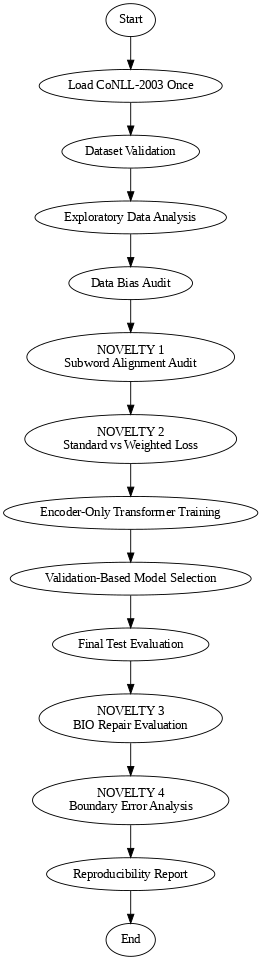

Flowchart Saved To: integrity_aware_ner_outputs/integrity_aware_ner_pipeline_flowchart.png


In [18]:
# Cell 17 — Machine Learning Pipeline Flowchart
# Komentar akademik:
# Cell ini membuat flowchart pipeline penelitian.
# Flowchart membantu pembaca memahami urutan proses dari data loading,
# EDA, audit bias, training, evaluasi, sampai laporan reproducibility.

# Validasi awal: pastikan SAVE_DIR sudah tersedia.
if "SAVE_DIR" not in globals():
    raise RuntimeError(
        "SAVE_DIR belum tersedia. Jalankan Cell 03 terlebih dahulu."
    )


# Komentar akademik:
# Graphviz digunakan karena mendukung representasi directed graph melalui Digraph.
# Struktur directed graph sesuai dengan pipeline penelitian yang berjalan dari awal ke akhir.
from graphviz import Digraph
from IPython.display import Image, display


dot = Digraph(
    comment="Integrity-Aware NER Pipeline"
)

# Komentar akademik:
# rankdir=TB berarti alur flowchart disusun dari atas ke bawah.
dot.attr(
    rankdir="TB",
    size="10"
)

# Node utama pipeline.
dot.node("A", "Start")
dot.node("B", "Load CoNLL-2003 Once")
dot.node("C", "Dataset Validation")
dot.node("D", "Exploratory Data Analysis")
dot.node("E", "Data Bias Audit")
dot.node("F", "NOVELTY 1\\nSubword Alignment Audit")
dot.node("G", "NOVELTY 2\\nStandard vs Weighted Loss")
dot.node("H", "Encoder-Only Transformer Training")
dot.node("I", "Validation-Based Model Selection")
dot.node("J", "Final Test Evaluation")
dot.node("K", "NOVELTY 3\\nBIO Repair Evaluation")
dot.node("L", "NOVELTY 4\\nBoundary Error Analysis")
dot.node("M", "Reproducibility Report")
dot.node("N", "End")


# Komentar akademik:
# Edge menunjukkan hubungan logis antar tahap penelitian.
edges = [
    ("A", "B"),
    ("B", "C"),
    ("C", "D"),
    ("D", "E"),
    ("E", "F"),
    ("F", "G"),
    ("G", "H"),
    ("H", "I"),
    ("I", "J"),
    ("J", "K"),
    ("K", "L"),
    ("L", "M"),
    ("M", "N"),
]

for edge in edges:
    dot.edge(*edge)


# Komentar akademik:
# Flowchart disimpan ke file PNG agar bisa dimasukkan ke laporan penelitian.
FLOWCHART_PATH = dot.render(
    str(SAVE_DIR / "integrity_aware_ner_pipeline_flowchart"),
    format="png",
    cleanup=True
)

print("Machine Learning Pipeline Flowchart")
display(Image(FLOWCHART_PATH))

print("Flowchart Saved To:", FLOWCHART_PATH)

In [19]:
# Cell 18 — Academic Report Template
# Komentar akademik:
# Cell ini membuat template laporan akademik berbasis output aktual program.
# Template ini tidak mengarang hasil; seluruh nilai performa diambil dari variabel
# yang sudah dihasilkan oleh proses training, validation, final test evaluation,
# dan boundary error analysis.

# Validasi awal: pastikan seluruh objek penting sudah tersedia.
required_objects = [
    "best_config",
    "bias_report",
    "test_metrics",
    "raw_f1",
    "raw_precision",
    "raw_recall",
    "repaired_f1",
    "repaired_precision",
    "repaired_recall",
    "dominant_error_type",
    "dominant_error_count"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Objek penting untuk membuat template laporan belum tersedia. "
        "Pastikan Cell 11 sampai Cell 16 sudah dijalankan tanpa error. "
        f"Missing objects: {missing_objects}"
    )


# Komentar akademik:
# Template ini ditulis dalam Bahasa Inggris karena bagian judul/output akademik
# diarahkan mengikuti gaya laporan internasional.
# Namun, struktur dan komentar tetap menjaga pembaca Indonesia memahami logikanya.
report_template = f"""
Title:
Integrity-Aware Encoder-Only Transformer Framework for Named Entity Recognition on CoNLL-2003:
Bias Audit, Reproducibility Control, and Boundary Error Analysis

Abstract Draft:
This study develops an integrity-aware Named Entity Recognition framework using an encoder-only Transformer
on the CoNLL-2003 dataset. The proposed pipeline integrates dataset validation, exploratory data analysis,
data bias audit, subword-label alignment audit, standard versus weighted loss comparison, validation-based
model selection, BIO repair evaluation, boundary error analysis, and reproducibility reporting. The best model
configuration was selected exclusively using the validation set to prevent test-set leakage.

Research Background:
Named Entity Recognition is a token classification task that assigns labels to individual tokens in a sentence,
such as person, location, organization, or miscellaneous entity. In this study, the CoNLL-2003 dataset is used
as the benchmark dataset for evaluating the proposed integrity-aware Transformer-based NER framework.

Research Gap:
Previous NER studies have explored Transformer-based modeling, domain-specific NER, low-resource NER,
few-shot NER, and prompt-based NER. However, many studies emphasize model performance without explicitly
integrating bias audit, subword alignment validation, BIO consistency analysis, and boundary-level error
taxonomy in a single reproducible pipeline.

Novelty:
The novelty of this study lies in an integrity-aware evaluation framework that combines:
1. data bias audit,
2. reproducibility control,
3. subword-label alignment audit,
4. standard versus weighted loss comparison,
5. BIO repair evaluation, and
6. boundary-level error analysis.

Method Summary:
The experiment was conducted using the following stages:
1. Load and validate CoNLL-2003 using a cache-aware dataset loader.
2. Perform exploratory data analysis on split size, label distribution, entity distribution, and sentence length.
3. Audit data imbalance, including O-label dominance and entity-type imbalance.
4. Tokenize input sequences and align word-level NER labels with subword tokens.
5. Train encoder-only Transformer configurations using standard loss and weighted loss.
6. Select the best configuration using validation repaired F1 only.
7. Evaluate the selected model once on the test set.
8. Analyze per-label performance, confusion matrix, BIO repair effect, and boundary errors.
9. Save reproducibility report and research artifacts.

Best Validation Configuration:
{best_config["experiment"]}

Final Test Results:
Raw Precision: {raw_precision:.4f}
Raw Recall: {raw_recall:.4f}
Raw F1: {raw_f1:.4f}

BIO-Repaired Precision: {repaired_precision:.4f}
BIO-Repaired Recall: {repaired_recall:.4f}
BIO-Repaired F1: {repaired_f1:.4f}

Bias Audit Summary:
O-to-non-O Ratio: {bias_report.get("o_to_non_o_ratio", np.nan):.4f}
Label Imbalance Ratio: {bias_report.get("label_imbalance_ratio", np.nan):.4f}
Entity-Type Imbalance Ratio Excluding O: {bias_report.get("entity_type_imbalance_ratio_excluding_O", np.nan):.4f}

Boundary Error Summary:
Dominant Boundary/Error Type: {dominant_error_type}
Dominant Boundary/Error Count: {dominant_error_count}

Interpretation:
The final model performance should be interpreted based on entity-level precision, recall, and F1 rather than
token-level accuracy. If BIO-repaired F1 is higher than raw F1, part of the model error may be associated with
BIO sequence inconsistency. If raw F1 is higher, raw prediction should remain the primary reported result.
Boundary error analysis provides additional insight into whether the model mainly suffers from missing entities,
spurious entities, boundary mismatch, or type mismatch.

Integrity Statement:
The test set was not used for model selection. The best configuration was selected using validation repaired F1.
BIO repair was applied only to model predictions and never to gold labels. All numerical results in this report
were generated from program outputs rather than manually inserted values.

Reproducibility Statement:
The experiment records seed, environment information, model configuration, dataset cache paths, training arguments,
test metrics, bias audit, and boundary error results. If FAST_RUN=True, the results are valid only for pipeline
verification and must not be claimed as final research findings.
"""


print("Academic Report Template")
print(report_template)


# Simpan template laporan ke file agar dapat digunakan dalam penyusunan artikel.
ACADEMIC_REPORT_TEMPLATE_TXT = SAVE_DIR / "academic_report_template.txt"

with open(
    ACADEMIC_REPORT_TEMPLATE_TXT,
    "w",
    encoding="utf-8"
) as f:
    f.write(report_template)

print("Academic Report Template Saved To:", ACADEMIC_REPORT_TEMPLATE_TXT)

Academic Report Template

Title:
Integrity-Aware Encoder-Only Transformer Framework for Named Entity Recognition on CoNLL-2003:
Bias Audit, Reproducibility Control, and Boundary Error Analysis

Abstract Draft:
This study develops an integrity-aware Named Entity Recognition framework using an encoder-only Transformer
on the CoNLL-2003 dataset. The proposed pipeline integrates dataset validation, exploratory data analysis,
data bias audit, subword-label alignment audit, standard versus weighted loss comparison, validation-based
model selection, BIO repair evaluation, boundary error analysis, and reproducibility reporting. The best model
configuration was selected exclusively using the validation set to prevent test-set leakage.

Research Background:
Named Entity Recognition is a token classification task that assigns labels to individual tokens in a sentence,
such as person, location, organization, or miscellaneous entity. In this study, the CoNLL-2003 dataset is used
as the benchmark da

In [20]:
# Cell 19 — Project Folder Governance and Error-Recovery Protocol
# Komentar akademik:
# Cell ini memastikan seluruh artefak penelitian disimpan dalam satu folder proyek.
# Tujuannya adalah menjaga keterlacakan file, memudahkan audit eksperimen,
# serta mendukung reproducibility laporan penelitian.

# Validasi awal: pastikan SAVE_DIR sudah tersedia dari Cell 03.
if "SAVE_DIR" not in globals():
    raise RuntimeError(
        "SAVE_DIR belum tersedia. Jalankan Cell 03 terlebih dahulu."
    )


# 1. Menetapkan folder utama proyek
PROJECT_ROOT = SAVE_DIR

# 2. Menetapkan subfolder standar untuk seluruh output penelitian
PROJECT_SUBDIRS = {
    "models": PROJECT_ROOT / "models",
    "reports": PROJECT_ROOT / "reports",
    "figures": PROJECT_ROOT / "figures",
    "app": PROJECT_ROOT / "streamlit_app",
    "logs": PROJECT_ROOT / "logs",
    "predictions": PROJECT_ROOT / "predictions",
    "deployment": PROJECT_ROOT / "deployment_bundle",
}

# Komentar akademik:
# pathlib.Path.mkdir dengan parents=True memungkinkan pembuatan folder induk
# jika belum tersedia, sedangkan exist_ok=True mencegah error jika folder sudah ada.
for folder in PROJECT_SUBDIRS.values():
    folder.mkdir(
        exist_ok=True,
        parents=True
    )


print("Project Folder Structure")

for name, folder in PROJECT_SUBDIRS.items():
    print(f"{name}: {folder}")


# 3. Membuat inventory awal folder proyek
# Komentar akademik:
# Inventory file membantu memastikan seluruh output dapat ditelusuri.
# Ini penting untuk dokumentasi eksperimen dan pemeriksaan ulang oleh reviewer/pembimbing.
folder_inventory_rows = []

for path in PROJECT_ROOT.rglob("*"):
    if path.is_file():
        folder_inventory_rows.append({
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "size_kb": round(path.stat().st_size / 1024, 2)
        })

folder_inventory_df = pd.DataFrame(folder_inventory_rows)

print("Initial Project Artifact Inventory")

if folder_inventory_df.empty:
    print("No artifact files found yet.")
else:
    display(
        folder_inventory_df.sort_values("relative_path")
    )


# 4. Mengecek kesiapan runtime untuk tahap deployment
# Komentar akademik:
# Deployment baru dapat dilakukan jika model terbaik, tokenizer, dan hasil evaluasi
# sudah tersedia dari cell sebelumnya.
required_runtime_objects = [
    "best_config",
    "test_metrics",
    "tokenizer",
    "model"
]

missing_runtime_objects = [
    obj
    for obj in required_runtime_objects
    if obj not in globals()
]

if missing_runtime_objects:
    print("Runtime Readiness Status: INCOMPLETE")
    print("Missing objects:", missing_runtime_objects)
    print(
        "Action: jalankan ulang cell training, final test evaluation, "
        "dan interpretasi sebelum tahap deployment."
    )
else:
    print("Runtime Readiness Status: READY")


# 5. Menyimpan governance report
# Komentar akademik:
# Governance report mencatat struktur folder, status runtime,
# dan daftar objek yang belum tersedia jika ada.
folder_governance_report = {
    "project_root": str(PROJECT_ROOT),
    "project_subdirs": {
        key: str(value)
        for key, value in PROJECT_SUBDIRS.items()
    },
    "runtime_readiness_status": (
        "READY"
        if not missing_runtime_objects
        else "INCOMPLETE"
    ),
    "missing_runtime_objects": missing_runtime_objects,
    "integrity_notes": [
        "All research artifacts should be stored under one project folder.",
        "Model files should be stored under models/.",
        "Reports should be stored under reports/.",
        "Predictions should be stored under predictions/.",
        "Streamlit application files should be stored under streamlit_app/.",
        "Deployment metadata should be stored under deployment_bundle/.",
        "Logs should be stored under logs/."
    ]
}

FOLDER_GOVERNANCE_JSON = (
    PROJECT_SUBDIRS["reports"] / "project_folder_governance_report.json"
)

with open(
    FOLDER_GOVERNANCE_JSON,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        folder_governance_report,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Project Folder Governance Report Saved To:", FOLDER_GOVERNANCE_JSON)


# 6. Menyimpan inventory file jika ada
FOLDER_INVENTORY_CSV = (
    PROJECT_SUBDIRS["reports"] / "initial_project_artifact_inventory.csv"
)

folder_inventory_df.to_csv(
    FOLDER_INVENTORY_CSV,
    index=False
)

print("Project Artifact Inventory Saved To:", FOLDER_INVENTORY_CSV)

Project Folder Structure
models: integrity_aware_ner_outputs/models
reports: integrity_aware_ner_outputs/reports
figures: integrity_aware_ner_outputs/figures
app: integrity_aware_ner_outputs/streamlit_app
logs: integrity_aware_ner_outputs/logs
predictions: integrity_aware_ner_outputs/predictions
deployment: integrity_aware_ner_outputs/deployment_bundle
Initial Project Artifact Inventory


,relative_path,size_kb
4,academic_report_template.txt,4.03
7,automatic_interpretation.txt,0.97
9,bias_report.json,0.24
12,conll2003_datasetdict/dataset_dict.json,0.04
25,conll2003_datasetdict/test/data-00000-of-00001.arrow,1548.86
...,...,...
67,tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300/train/state.json,0.24
65,tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300/validation/data-00000-of-00001.arrow,85.15
63,tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300/validation/dataset_info.json,1.80
64,tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300/validation/state.json,0.25


Runtime Readiness Status: READY
Project Folder Governance Report Saved To: integrity_aware_ner_outputs/reports/project_folder_governance_report.json
Project Artifact Inventory Saved To: integrity_aware_ner_outputs/reports/initial_project_artifact_inventory.csv


In [21]:
# Cell 20 — Save Best Model and Deployment Bundle
# Komentar akademik:
# Cell ini menyimpan model terbaik, tokenizer, dan deployment manifest.
# Untuk model Transformer, penyimpanan utama yang benar adalah save_pretrained(),
# bukan joblib. Joblib digunakan sebagai manifest metadata deployment, bukan
# sebagai format utama penyimpanan bobot neural network.

# Validasi awal: pastikan folder proyek dan objek penting sudah tersedia.
required_objects = [
    "PROJECT_SUBDIRS",
    "best_config",
    "test_metrics",
    "model",
    "tokenizer",
    "label_names",
    "id2label",
    "label2id"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Objek penting untuk menyimpan model belum tersedia. "
        "Pastikan Cell 11 sampai Cell 19 sudah dijalankan tanpa error. "
        f"Missing objects: {missing_objects}"
    )


# Import tambahan untuk deployment manifest.
import joblib
from datetime import datetime


# 1. Menetapkan direktori ekspor model terbaik.
MODEL_EXPORT_DIR = PROJECT_SUBDIRS["models"] / "best_ner_model"

MODEL_EXPORT_DIR.mkdir(
    exist_ok=True,
    parents=True
)


# 2. Menyimpan model dan tokenizer dalam format Hugging Face.
# Komentar akademik:
# save_pretrained() menyimpan bobot model, konfigurasi, tokenizer, dan file pendukung
# agar dapat dimuat kembali menggunakan from_pretrained().
model.save_pretrained(
    str(MODEL_EXPORT_DIR)
)

tokenizer.save_pretrained(
    str(MODEL_EXPORT_DIR)
)


# 3. Membuat deployment manifest.
# Komentar akademik:
# Manifest ini menyimpan metadata eksperimen, path model, konfigurasi terbaik,
# dan hasil evaluasi. Ia membantu deployment tanpa mengubah format penyimpanan
# bobot Transformer.
deployment_manifest = {
    "program_title": (
        "Integrity-Aware Named Entity Recognition with Encoder-Only Transformer "
        "on CoNLL-2003"
    ),
    "created_at": datetime.now().isoformat(),
    "model_storage_format": "huggingface_save_pretrained",
    "model_export_dir": str(MODEL_EXPORT_DIR),
    "joblib_role": "deployment_manifest_and_metadata",
    "best_config": best_config,
    "test_metrics": {
        k: float(v) if isinstance(v, (int, float, np.floating)) else str(v)
        for k, v in test_metrics.items()
    },
    "label_names": label_names,
    "id2label": {
        int(k): v
        for k, v in id2label.items()
    },
    "label2id": {
        k: int(v)
        for k, v in label2id.items()
    },
    "integrity_note": (
        "Transformer weights are stored using Hugging Face save_pretrained. "
        "Joblib stores only metadata, model path, configuration, and deployment notes. "
        "This avoids unstable or unsafe serialization of large neural network objects."
    ),
    "security_note": (
        "Only load this joblib manifest from a trusted source because joblib uses "
        "pickle-based serialization."
    )
}


# 4. Menyimpan manifest dalam format joblib dan JSON.
JOBLIB_BUNDLE_PATH = (
    PROJECT_SUBDIRS["deployment"] / "ner_deployment_manifest.joblib"
)

MANIFEST_JSON_PATH = (
    PROJECT_SUBDIRS["deployment"] / "ner_deployment_manifest.json"
)

joblib.dump(
    deployment_manifest,
    JOBLIB_BUNDLE_PATH
)

with open(
    MANIFEST_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        deployment_manifest,
        f,
        indent=2,
        ensure_ascii=False
    )


# 5. Membuat ringkasan file model yang tersimpan.
model_file_rows = []

for path in MODEL_EXPORT_DIR.rglob("*"):
    if path.is_file():
        model_file_rows.append({
            "relative_path": str(path.relative_to(MODEL_EXPORT_DIR)),
            "size_kb": round(path.stat().st_size / 1024, 2)
        })

model_files_df = pd.DataFrame(model_file_rows)

MODEL_FILES_INVENTORY_CSV = (
    PROJECT_SUBDIRS["reports"] / "model_export_file_inventory.csv"
)

model_files_df.to_csv(
    MODEL_FILES_INVENTORY_CSV,
    index=False
)


print("Model Export Summary")
print("Hugging Face Model Directory:", MODEL_EXPORT_DIR)
print("Joblib Deployment Manifest:", JOBLIB_BUNDLE_PATH)
print("JSON Deployment Manifest:", MANIFEST_JSON_PATH)
print("Model File Inventory:", MODEL_FILES_INVENTORY_CSV)

print("Model Exported Files")
display(model_files_df)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Export Summary
Hugging Face Model Directory: integrity_aware_ner_outputs/models/best_ner_model
Joblib Deployment Manifest: integrity_aware_ner_outputs/deployment_bundle/ner_deployment_manifest.joblib
JSON Deployment Manifest: integrity_aware_ner_outputs/deployment_bundle/ner_deployment_manifest.json
Model File Inventory: integrity_aware_ner_outputs/reports/model_export_file_inventory.csv
Model Exported Files


,relative_path,size_kb
0,config.json,0.95
1,tokenizer.json,653.25
2,tokenizer_config.json,0.32
3,model.safetensors,254691.08


In [23]:
# Cell 21 — Simple New-Data Testing with Seven Sentences
# Komentar akademik:
# Cell ini melakukan pengujian sederhana pada tujuh kalimat baru.
# Tujuannya adalah memastikan model yang sudah disimpan dapat menerima input baru
# dan menghasilkan prediksi NER secara fungsional.
#
# Revisi error:
# Error "Object of type float32 is not JSON serializable" diperbaiki dengan
# fungsi make_json_serializable(), yaitu mengubah tipe NumPy menjadi tipe Python native.
#
# Catatan integritas:
# Pengujian ini bukan benchmark resmi dan tidak menggantikan test set CoNLL-2003.
# Pengujian ini hanya sanity check untuk tahap deployment.

# Validasi awal: pastikan model export directory dan folder proyek tersedia.
required_objects = [
    "MODEL_EXPORT_DIR",
    "PROJECT_SUBDIRS"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Objek penting untuk pengujian data baru belum tersedia. "
        "Pastikan Cell 19 dan Cell 20 sudah dijalankan tanpa error. "
        f"Missing objects: {missing_objects}"
    )

if not MODEL_EXPORT_DIR.exists():
    raise RuntimeError(
        "MODEL_EXPORT_DIR belum tersedia di disk. "
        "Jalankan Cell 20 terlebih dahulu untuk menyimpan model dan tokenizer."
    )


def make_json_serializable(obj):
    # Komentar akademik:
    # Fungsi rekursif ini memastikan seluruh output prediksi dapat disimpan ke JSON.
    # NumPy scalar seperti np.float32, np.float64, np.int64 diubah menjadi tipe Python native.
    # NumPy array diubah menjadi list.
    # Dictionary dan list diproses secara rekursif.

    if isinstance(obj, dict):
        return {
            str(key): make_json_serializable(value)
            for key, value in obj.items()
        }

    if isinstance(obj, list):
        return [
            make_json_serializable(item)
            for item in obj
        ]

    if isinstance(obj, tuple):
        return [
            make_json_serializable(item)
            for item in obj
        ]

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, np.generic):
        return obj.item()

    return obj


# Komentar akademik:
# Hugging Face pipeline digunakan untuk inference karena menyediakan API sederhana
# untuk task token-classification/NER.
# aggregation_strategy='simple' digunakan untuk menggabungkan token/subword
# menjadi entitas yang lebih mudah dibaca.
from transformers import pipeline

pipeline_device = 0 if torch.cuda.is_available() else -1

ner_inference_pipeline = pipeline(
    task="token-classification",
    model=str(MODEL_EXPORT_DIR),
    tokenizer=str(MODEL_EXPORT_DIR),
    aggregation_strategy="simple",
    device=pipeline_device
)


# Komentar akademik:
# Tujuh kalimat berikut dibuat untuk mengandung variasi entitas:
# person, organization, location, dan miscellaneous context.
# Hasilnya digunakan untuk memeriksa apakah model berjalan secara fungsional
# pada data baru di luar split train/validation/test.
new_test_sentences = [
    "Barack Obama visited Berlin during an international diplomatic meeting.",
    "Microsoft opened a new research center in Singapore.",
    "The United Nations held a climate summit in Geneva.",
    "Serena Williams met journalists in London after the tournament.",
    "Toyota announced a partnership with Panasonic in Tokyo.",
    "Amazon Web Services expanded its cloud infrastructure in Jakarta.",
    "Lionel Messi joined a charity event organized by UNICEF in Paris."
]


new_predictions = []

for idx, sentence in enumerate(new_test_sentences, start=1):
    entities = ner_inference_pipeline(sentence)

    # Komentar akademik:
    # Output pipeline dikonversi segera agar aman disimpan ke JSON.
    entities = make_json_serializable(entities)

    new_predictions.append({
        "id": int(idx),
        "sentence": str(sentence),
        "entities": entities
    })


# Komentar akademik:
# Hasil prediksi dibuat dalam format flat table agar mudah dibaca,
# disimpan, dan dianalisis pada tahap deployment.
flat_rows = []

for item in new_predictions:

    if item["entities"]:
        for ent in item["entities"]:
            score_value = ent.get("score", None)

            if score_value is not None:
                score_value = round(float(score_value), 4)

            flat_rows.append({
                "id": int(item["id"]),
                "sentence": str(item["sentence"]),
                "entity_group": ent.get("entity_group"),
                "word": ent.get("word"),
                "score": score_value,
                "start": int(ent["start"]) if ent.get("start") is not None else None,
                "end": int(ent["end"]) if ent.get("end") is not None else None,
            })

    else:
        flat_rows.append({
            "id": int(item["id"]),
            "sentence": str(item["sentence"]),
            "entity_group": None,
            "word": None,
            "score": None,
            "start": None,
            "end": None,
        })


new_predictions_df = pd.DataFrame(flat_rows)

print("New Data Sanity Test Predictions")
display(new_predictions_df)


# Komentar akademik:
# Simpan prediksi dalam dua format:
# JSON untuk struktur lengkap, CSV untuk analisis tabular.
NEW_PREDICTIONS_JSON = (
    PROJECT_SUBDIRS["predictions"] / "new_data_sanity_test_predictions.json"
)

NEW_PREDICTIONS_CSV = (
    PROJECT_SUBDIRS["predictions"] / "new_data_sanity_test_predictions.csv"
)

# Komentar akademik:
# Sebelum json.dump(), seluruh struktur dipastikan JSON serializable.
safe_new_predictions = make_json_serializable(new_predictions)

with open(
    NEW_PREDICTIONS_JSON,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        safe_new_predictions,
        f,
        indent=2,
        ensure_ascii=False
    )

new_predictions_df.to_csv(
    NEW_PREDICTIONS_CSV,
    index=False
)


print("New Data Prediction Files")
print("JSON:", NEW_PREDICTIONS_JSON)
print("CSV:", NEW_PREDICTIONS_CSV)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

New Data Sanity Test Predictions


,id,sentence,entity_group,word,score,start,end
0,1,Barack Obama visited Berlin during an international diplomatic meeting.,PER,Barack Obama,0.2892,0,12
1,1,Barack Obama visited Berlin during an international diplomatic meeting.,LOC,Berlin,0.5890,21,27
2,2,Microsoft opened a new research center in Singapore.,LOC,Microsoft,0.3055,0,9
3,2,Microsoft opened a new research center in Singapore.,LOC,Singapore,0.4158,42,51
4,3,The United Nations held a climate summit in Geneva.,MISC,United,0.4138,4,10
5,3,The United Nations held a climate summit in Geneva.,ORG,Nations,0.3271,11,18
6,3,The United Nations held a climate summit in Geneva.,LOC,Geneva,0.4845,44,50
7,4,Serena Williams met journalists in London after the tournament.,PER,Serena Williams,0.3963,0,15
8,5,Toyota announced a partnership with Panasonic in Tokyo.,MISC,Toyota,0.2601,0,6
9,5,Toyota announced a partnership with Panasonic in Tokyo.,ORG,Pan,0.2455,36,39


New Data Prediction Files
JSON: integrity_aware_ner_outputs/predictions/new_data_sanity_test_predictions.json
CSV: integrity_aware_ner_outputs/predictions/new_data_sanity_test_predictions.csv


In [24]:
# Cell 22 — Build Streamlit Dashboard Application
# Komentar akademik:
# Cell ini membuat file app.py untuk dashboard Streamlit.
# Dashboard memuat model NER yang sudah disimpan, menerima input teks baru,
# menjalankan prediksi NER, dan menampilkan hasil dalam tabel serta JSON.
#
# Catatan integritas:
# Dashboard ini adalah prototype deployment, bukan alat untuk mengklaim performa final.
# Klaim performa final tetap harus berdasarkan test set resmi dari Cell 13.

# Validasi awal: pastikan file model dan manifest deployment tersedia.
required_objects = [
    "PROJECT_ROOT",
    "PROJECT_SUBDIRS",
    "MODEL_EXPORT_DIR",
    "JOBLIB_BUNDLE_PATH"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Objek penting untuk membangun Streamlit dashboard belum tersedia. "
        "Pastikan Cell 19 dan Cell 20 sudah dijalankan tanpa error. "
        f"Missing objects: {missing_objects}"
    )

if not MODEL_EXPORT_DIR.exists():
    raise RuntimeError(
        "MODEL_EXPORT_DIR belum tersedia di disk. "
        "Jalankan Cell 20 terlebih dahulu."
    )

if not JOBLIB_BUNDLE_PATH.exists():
    raise RuntimeError(
        "JOBLIB_BUNDLE_PATH belum tersedia di disk. "
        "Jalankan Cell 20 terlebih dahulu."
    )


# Menetapkan lokasi file aplikasi Streamlit.
APP_FILE = PROJECT_SUBDIRS["app"] / "app.py"


# Komentar akademik:
# app.py ditulis sebagai file mandiri agar deployment dapat direproduksi.
# st.cache_resource digunakan untuk caching model/pipeline karena model merupakan
# resource global yang mahal dimuat berulang.
streamlit_app_code = f'''
import json
from pathlib import Path

import joblib
import pandas as pd
import streamlit as st
from transformers import pipeline


st.set_page_config(
    page_title="Integrity-Aware NER Dashboard",
    page_icon="🔎",
    layout="wide"
)


st.title("Integrity-Aware Named Entity Recognition Dashboard")
st.caption(
    "Encoder-Only Transformer for CoNLL-2003 NER | "
    "Interactive deployment prototype with transparent model metadata."
)


PROJECT_ROOT = Path(r"{str(PROJECT_ROOT.resolve())}")
MANIFEST_PATH = Path(r"{str(JOBLIB_BUNDLE_PATH.resolve())}")


def make_json_serializable(obj):
    # Komentar akademik:
    # Fungsi ini menjaga agar output prediksi aman ditampilkan sebagai JSON
    # jika pipeline menghasilkan tipe data non-native.
    try:
        import numpy as np
    except Exception:
        np = None

    if isinstance(obj, dict):
        return {{
            str(key): make_json_serializable(value)
            for key, value in obj.items()
        }}

    if isinstance(obj, list):
        return [
            make_json_serializable(item)
            for item in obj
        ]

    if isinstance(obj, tuple):
        return [
            make_json_serializable(item)
            for item in obj
        ]

    if np is not None and isinstance(obj, np.ndarray):
        return obj.tolist()

    if np is not None and isinstance(obj, np.generic):
        return obj.item()

    return obj


@st.cache_resource
def load_ner_pipeline():
    # Komentar akademik:
    # Manifest joblib memuat metadata dan path model, bukan bobot utama Transformer.
    # Bobot utama tetap dimuat dari direktori save_pretrained().
    manifest = joblib.load(MANIFEST_PATH)
    model_dir = manifest["model_export_dir"]

    ner_pipe = pipeline(
        task="token-classification",
        model=model_dir,
        tokenizer=model_dir,
        aggregation_strategy="simple"
    )

    return ner_pipe, manifest


ner_pipe, manifest = load_ner_pipeline()


with st.sidebar:
    st.header("Model Metadata")
    st.write("Model format:", manifest.get("model_storage_format"))
    st.write("Best experiment:", manifest.get("best_config", {{}}).get("experiment"))
    st.write("Joblib role:", manifest.get("joblib_role"))

    st.info(
        "This dashboard is a deployment prototype. "
        "Final scientific claims must use the official validation-selected test-set metrics."
    )

    with st.expander("Integrity Metadata"):
        st.json({{
            "model_export_dir": manifest.get("model_export_dir"),
            "test_metrics": manifest.get("test_metrics"),
            "integrity_note": manifest.get("integrity_note"),
        }})


sample_texts = [
    "Barack Obama visited Berlin during an international diplomatic meeting.",
    "Microsoft opened a new research center in Singapore.",
    "The United Nations held a climate summit in Geneva.",
    "Serena Williams met journalists in London after the tournament.",
    "Toyota announced a partnership with Panasonic in Tokyo.",
    "Amazon Web Services expanded its cloud infrastructure in Jakarta.",
    "Lionel Messi joined a charity event organized by UNICEF in Paris."
]


st.subheader("Input Text")

selected_sample = st.selectbox(
    "Select a sample sentence",
    ["Custom input"] + sample_texts
)


if selected_sample == "Custom input":
    text_input = st.text_area(
        "Enter text for NER prediction",
        value="Google opened a new office in Jakarta with support from Sundar Pichai.",
        height=120
    )

else:
    text_input = st.text_area(
        "Enter text for NER prediction",
        value=selected_sample,
        height=120
    )


if st.button("Run NER Prediction"):
    if not text_input.strip():
        st.warning("Please enter a non-empty sentence.")

    else:
        predictions = ner_pipe(text_input)
        predictions = make_json_serializable(predictions)

        rows = []

        for ent in predictions:
            score_value = ent.get("score", None)

            if score_value is not None:
                score_value = round(float(score_value), 4)

            rows.append({{
                "Entity": ent.get("word"),
                "Entity Group": ent.get("entity_group"),
                "Score": score_value,
                "Start": ent.get("start"),
                "End": ent.get("end"),
            }})

        st.subheader("Prediction Output")

        if rows:
            st.dataframe(
                pd.DataFrame(rows),
                use_container_width=True
            )

        else:
            st.info("No named entity was detected.")

        st.subheader("Raw Prediction JSON")
        st.json(predictions)


st.subheader("Integrity Note")
st.write(
    "The dashboard loads the model from the exported model directory and reads deployment metadata "
    "from a joblib manifest. The official research result must be based on validation-selected "
    "final test evaluation, not on interactive examples."
)
'''


# Menulis file app.py ke folder proyek.
with open(
    APP_FILE,
    "w",
    encoding="utf-8"
) as f:
    f.write(streamlit_app_code)


print("Streamlit Application File")
print(APP_FILE)


# Menampilkan preview ringkas isi awal file.
with open(
    APP_FILE,
    "r",
    encoding="utf-8"
) as f:
    preview_lines = f.readlines()[:30]

print("Streamlit App Preview")
print("".join(preview_lines))

Streamlit Application File
integrity_aware_ner_outputs/streamlit_app/app.py
Streamlit App Preview

import json
from pathlib import Path

import joblib
import pandas as pd
import streamlit as st
from transformers import pipeline


st.set_page_config(
    page_title="Integrity-Aware NER Dashboard",
    page_icon="🔎",
    layout="wide"
)


st.title("Integrity-Aware Named Entity Recognition Dashboard")
st.caption(
    "Encoder-Only Transformer for CoNLL-2003 NER | "
    "Interactive deployment prototype with transparent model metadata."
)


PROJECT_ROOT = Path(r"/content/integrity_aware_ner_outputs")
MANIFEST_PATH = Path(r"/content/integrity_aware_ner_outputs/deployment_bundle/ner_deployment_manifest.joblib")


def make_json_serializable(obj):
    # Komentar akademik:



In [25]:
# Cell 23 — Run Streamlit Dashboard in Google Colab with Manual Hidden ngrok Token
# Komentar akademik:
# Cell ini menjalankan dashboard Streamlit di Google Colab dan membuat public URL
# menggunakan ngrok melalui pyngrok.
#
# Catatan keamanan:
# Token ngrok tidak ditulis langsung di kode.
# Token dimasukkan secara manual menggunakan getpass(), sehingga tidak tampil di output notebook.
# Setelah digunakan, variabel token dihapus dari memori lokal cell.

# Validasi awal: pastikan app.py sudah dibuat.
required_objects = [
    "APP_FILE",
    "PROJECT_SUBDIRS"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Objek penting untuk menjalankan Streamlit dashboard belum tersedia. "
        "Pastikan Cell 22 sudah dijalankan tanpa error. "
        f"Missing objects: {missing_objects}"
    )

if not APP_FILE.exists():
    raise RuntimeError(
        "File app.py belum tersedia. Jalankan Cell 22 terlebih dahulu."
    )


# Komentar akademik:
# Instalasi dilakukan di cell ini agar Colab runtime memiliki Streamlit dan pyngrok
# sebelum dashboard dijalankan.
!pip -q install streamlit pyngrok


import time
import subprocess
from getpass import getpass
from pyngrok import ngrok


# Komentar akademik:
# Jika ada tunnel lama, tunnel ditutup terlebih dahulu agar tidak terjadi konflik port.
try:
    ngrok.kill()
except Exception as cleanup_error:
    print("Ngrok cleanup note:", cleanup_error)


# Komentar akademik:
# Token dimasukkan manual dan tersembunyi.
# Jangan menulis token langsung di notebook.
ngrok_token = getpass("Enter your ngrok authtoken (hidden input): ")

if not ngrok_token.strip():
    raise ValueError(
        "Ngrok token kosong. Masukkan token secara manual untuk membuat public URL."
    )


# Komentar akademik:
# set_auth_token digunakan agar pyngrok dapat membuat tunnel dengan akun pengguna.
ngrok.set_auth_token(
    ngrok_token.strip()
)


# Komentar akademik:
# Token dihapus dari variabel lokal setelah dipakai.
ngrok_token = None
del ngrok_token


STREAMLIT_PORT = 8501
STREAMLIT_LOG = PROJECT_SUBDIRS["logs"] / "streamlit_app.log"


# Komentar akademik:
# Streamlit dijalankan sebagai subprocess agar notebook tetap dapat melanjutkan
# pembuatan tunnel ngrok.
#
# --server.address 0.0.0.0 membuat server menerima koneksi dari tunnel.
# --server.headless true mencegah Streamlit mencoba membuka browser lokal.
streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        str(APP_FILE),
        "--server.port",
        str(STREAMLIT_PORT),
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true",
    ],
    stdout=open(STREAMLIT_LOG, "w"),
    stderr=subprocess.STDOUT,
)


# Komentar akademik:
# Beri waktu beberapa detik agar Streamlit server aktif sebelum tunnel dibuat.
time.sleep(8)


# Komentar akademik:
# ngrok.connect membuat public URL yang mengarah ke port Streamlit.
public_url = ngrok.connect(
    STREAMLIT_PORT
).public_url


print("Streamlit Dashboard Public URL")
print(public_url)

print("Streamlit Process PID:", streamlit_process.pid)
print("Streamlit Log File:", STREAMLIT_LOG)
print(
    "Security Note: ngrok token was entered with hidden input and removed "
    "from the local variable after authentication."
)

Enter your ngrok authtoken (hidden input): ··········
Streamlit Dashboard Public URL
https://edginess-reunion-marshland.ngrok-free.dev
Streamlit Process PID: 8274
Streamlit Log File: integrity_aware_ner_outputs/logs/streamlit_app.log
Security Note: ngrok token was entered with hidden input and removed from the local variable after authentication.


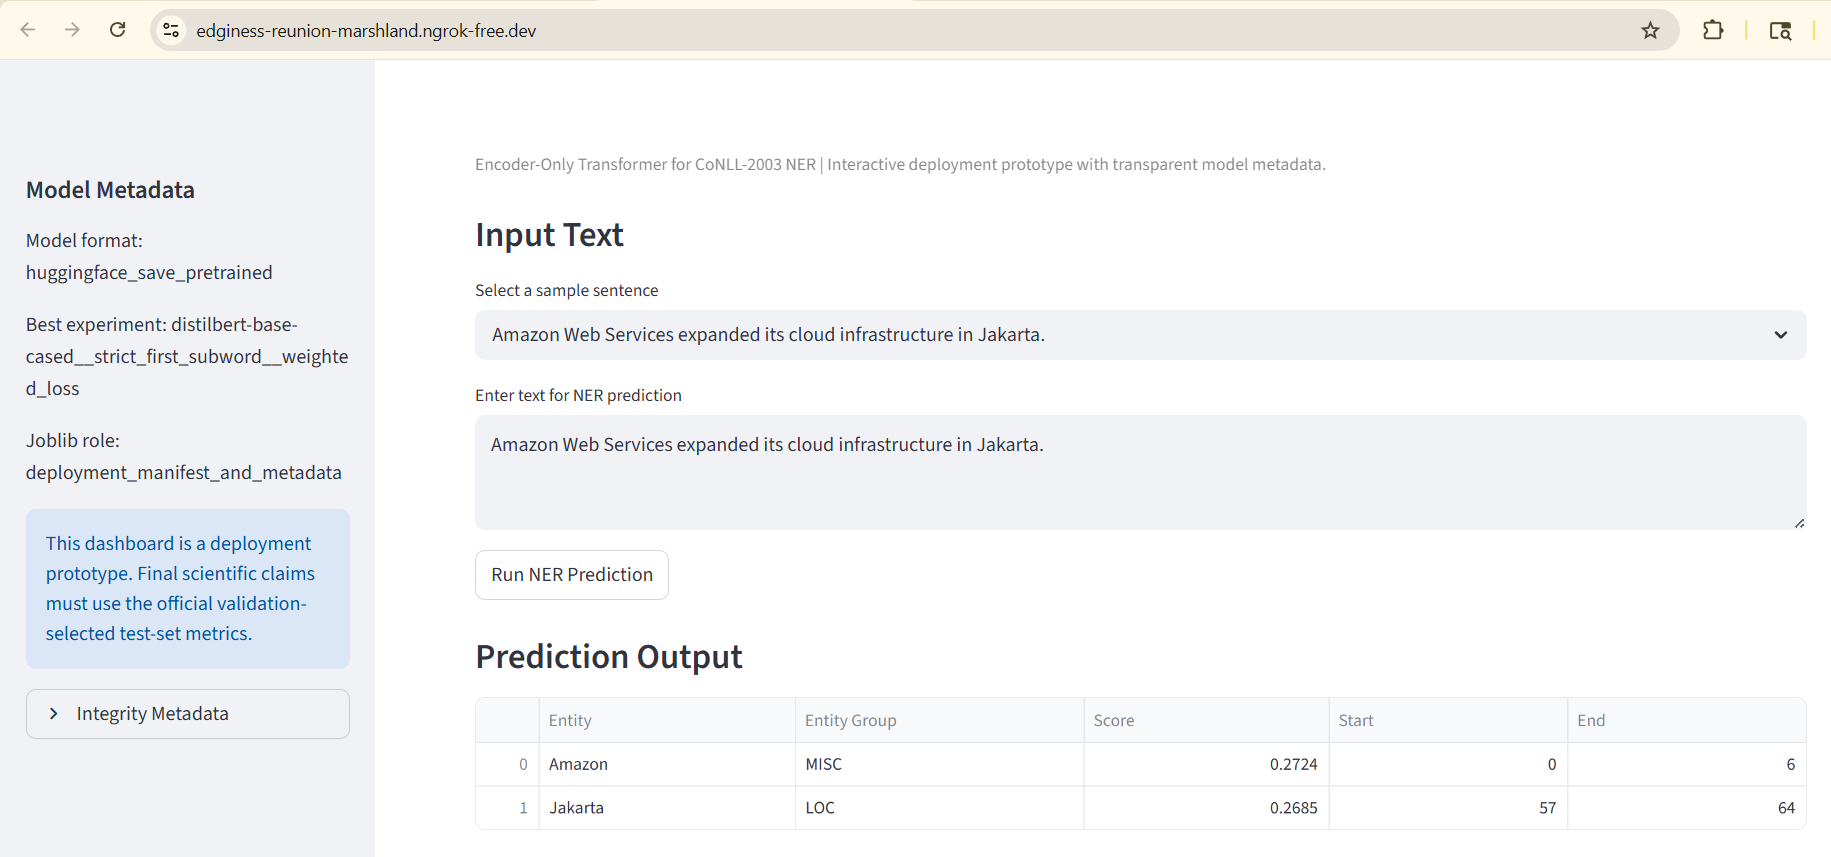

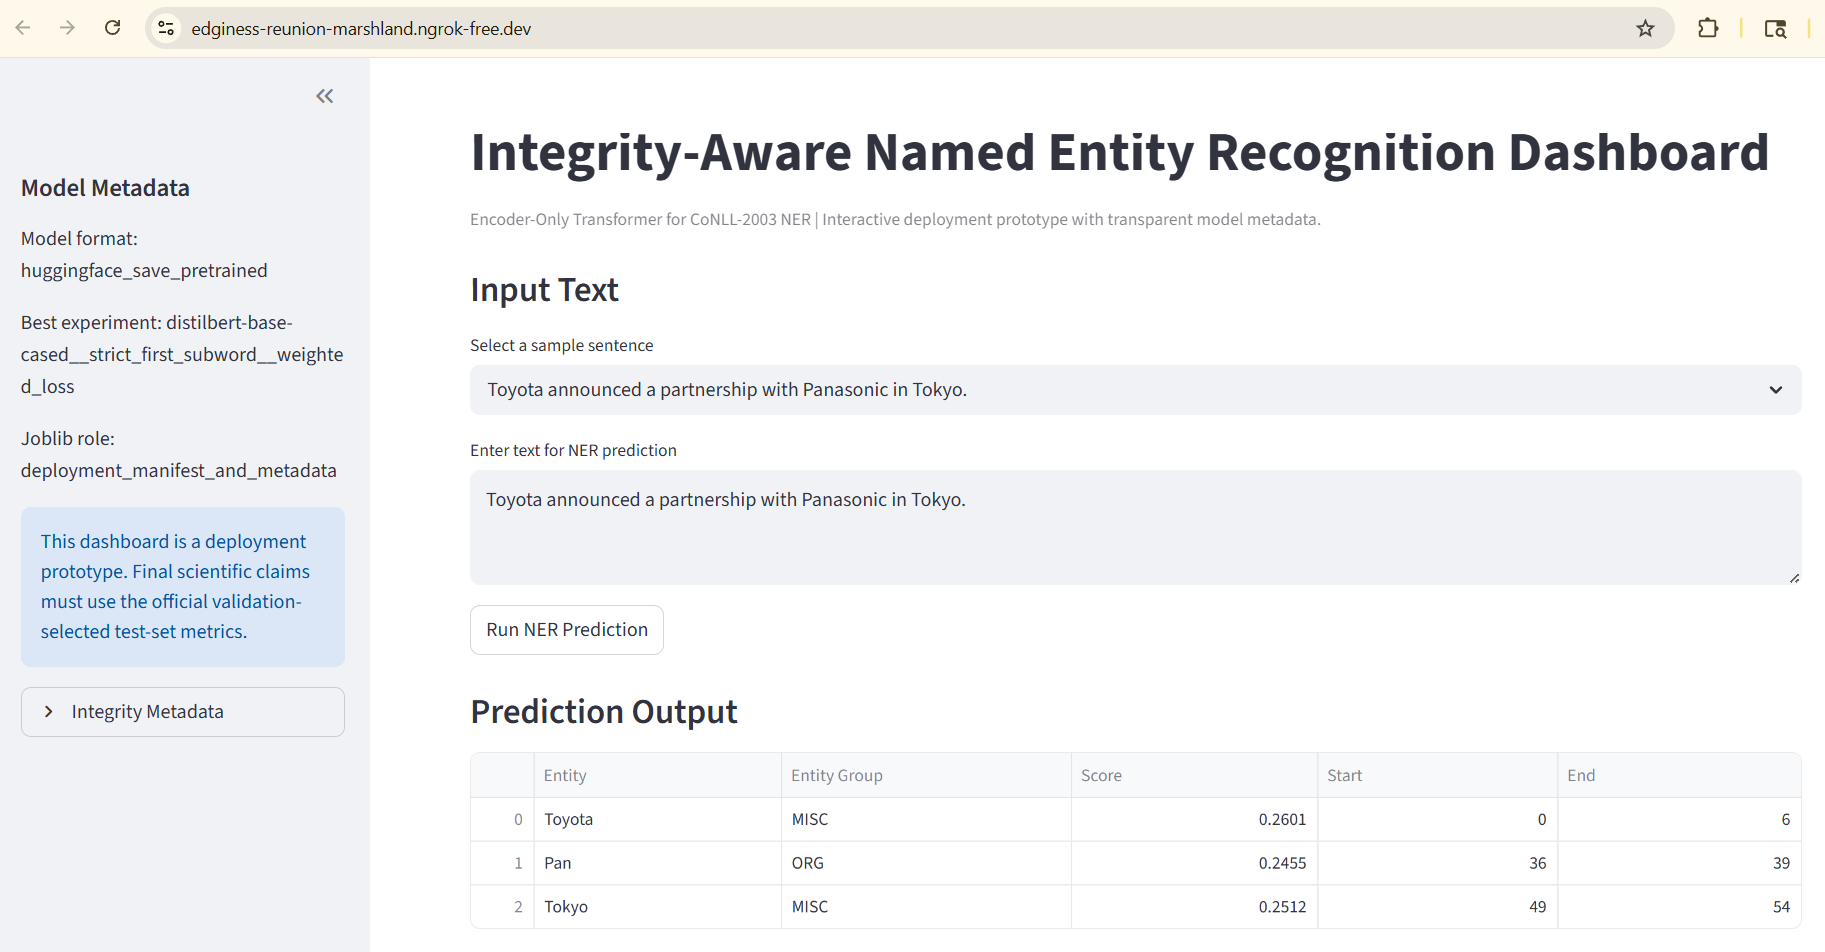

In [26]:
# Cell 24 — Package All Research Outputs into One Folder Archive
# Komentar akademik:
# Cell ini mengarsipkan seluruh folder proyek ke dalam file .zip.
# Tujuannya adalah memastikan seluruh artefak penelitian dapat disimpan,
# dibagikan, diaudit, dan direplikasi secara konsisten.

# Validasi awal: pastikan folder proyek tersedia.
required_objects = [
    "PROJECT_ROOT",
    "PROJECT_SUBDIRS"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Objek penting untuk packaging belum tersedia. "
        "Pastikan Cell 19 sudah dijalankan tanpa error. "
        f"Missing objects: {missing_objects}"
    )

if not PROJECT_ROOT.exists():
    raise RuntimeError(
        "PROJECT_ROOT tidak ditemukan di disk. "
        "Pastikan folder proyek sudah dibuat pada Cell 19."
    )


# Komentar akademik:
# shutil.make_archive digunakan untuk membuat arsip .zip dari folder proyek.
# base_name tidak perlu diberi ekstensi .zip karena fungsi ini akan menambahkannya otomatis.
import shutil
from datetime import datetime


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

ARCHIVE_BASE_NAME = (
    PROJECT_ROOT.parent / f"{PROJECT_ROOT.name}_archive_{timestamp}"
)

ARCHIVE_PATH = shutil.make_archive(
    base_name=str(ARCHIVE_BASE_NAME),
    format="zip",
    root_dir=str(PROJECT_ROOT.parent),
    base_dir=str(PROJECT_ROOT.name)
)


print("Research Output Archive")
print(ARCHIVE_PATH)


# Komentar akademik:
# Inventory akhir dibuat setelah packaging agar semua file terbaru tercatat.
final_folder_summary = []

for path in PROJECT_ROOT.rglob("*"):
    if path.is_file():
        final_folder_summary.append({
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "size_kb": round(path.stat().st_size / 1024, 2)
        })

final_folder_summary_df = (
    pd.DataFrame(final_folder_summary)
    .sort_values("relative_path")
    .reset_index(drop=True)
)

print("Final Project Artifact Inventory")
display(final_folder_summary_df)


# Simpan inventory akhir ke folder reports.
FINAL_INVENTORY_CSV = (
    PROJECT_SUBDIRS["reports"] / "final_project_artifact_inventory.csv"
)

final_folder_summary_df.to_csv(
    FINAL_INVENTORY_CSV,
    index=False
)


# Komentar akademik:
# Packaging report mencatat lokasi arsip, jumlah file, dan total ukuran artefak.
total_size_kb = (
    final_folder_summary_df["size_kb"].sum()
    if not final_folder_summary_df.empty
    else 0.0
)

packaging_report = {
    "archive_path": str(ARCHIVE_PATH),
    "project_root": str(PROJECT_ROOT),
    "num_files": int(len(final_folder_summary_df)),
    "total_size_kb": float(total_size_kb),
    "inventory_csv": str(FINAL_INVENTORY_CSV),
    "integrity_notes": [
        "All available research artifacts were packaged from one project folder.",
        "The archive includes model files, reports, predictions, app files, logs, and deployment metadata if they exist.",
        "The archive should be regenerated after rerunning training or deployment cells.",
        "Do not use FAST_RUN=True results as final publication claims."
    ]
}

PACKAGING_REPORT_JSON = (
    PROJECT_SUBDIRS["reports"] / "packaging_report.json"
)

with open(
    PACKAGING_REPORT_JSON,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        packaging_report,
        f,
        indent=2,
        ensure_ascii=False
    )


print("Packaging Report Saved To:", PACKAGING_REPORT_JSON)
print("Final Inventory Saved To:", FINAL_INVENTORY_CSV)
print("Archive File:", ARCHIVE_PATH)

Research Output Archive
/content/integrity_aware_ner_outputs_archive_20260506_104801.zip
Final Project Artifact Inventory


,relative_path,size_kb
0,academic_report_template.txt,4.03
1,automatic_interpretation.txt,0.97
2,bias_report.json,0.24
3,conll2003_datasetdict/dataset_dict.json,0.04
4,conll2003_datasetdict/test/data-00000-of-00001.arrow,1548.86
...,...,...
164,tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300/train/state.json,0.24
165,tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300/validation/data-00000-of-00001.arrow,85.15
166,tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300/validation/dataset_info.json,1.80
167,tokenized_cache/distilbert-base-cased__strict_first_subword_alltok0__fast__train600_eval300/validation/state.json,0.25


Packaging Report Saved To: integrity_aware_ner_outputs/reports/packaging_report.json
Final Inventory Saved To: integrity_aware_ner_outputs/reports/final_project_artifact_inventory.csv
Archive File: /content/integrity_aware_ner_outputs_archive_20260506_104801.zip
